# Full project notebook

## All imports

In [31]:
import os
import re
import glob
import nltk
import math
import json
import torch
import random
import hashlib
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.stats import norm
from wordcloud import WordCloud
from nltk.corpus import stopwords
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist
from sklearn.preprocessing import normalize
from collections import defaultdict, Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge, LogisticRegression
from transformers import AutoTokenizer, AutoConfig, AutoModel

PROJECT_ROOT = "."

## Data preparation

We first gather the datasets that we are going to use for this study. 
One dataset is used for training and validation, a separate dataset is used to test it on a completely different corpus.

In [2]:

os.makedirs("plots", exist_ok=True)
os.makedirs("datasets", exist_ok=True)

files = {
    "datasets/All_Beauty.jsonl": "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl",
    "datasets/Handmade_Products.jsonl": "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Handmade_Products.jsonl",
}

for path, url in files.items():
    if not (os.path.exists(path) or os.path.exists(path.replace(".jsonl", "_f.jsonl"))):
        import urllib.request
        urllib.request.urlretrieve(url, path)


After downloading, we filter the dataset to remove all unnecessary information and use fixed category sizes.

In [3]:
def filter_jsonl(input_path, output_path, max_per_rating=50000):
    keep_keys = {"rating", "title", "text"}
    rating_counts_before = defaultdict(int)
    rating_counts_after = defaultdict(int)

    # First pass: count existing reviews per rating
    with open(input_path, "r", encoding="utf-8") as fin:
        for line in fin:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                rating = int(data.get("rating", 0))
                if rating in [1, 2, 3, 4, 5]:
                    rating_counts_before[rating] += 1
            except json.JSONDecodeError:
                continue

    # Second pass: write filtered output with limit
    with (
        open(input_path, "r", encoding="utf-8") as fin,
        open(output_path, "w", encoding="utf-8") as fout,
    ):
        for line in fin:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                rating = int(data.get("rating", 0))
                if rating not in [1, 2, 3, 4, 5]:
                    continue
                if rating_counts_after[rating] >= max_per_rating:
                    continue

                filtered = {k: data[k] for k in keep_keys if k in data}
                fout.write(json.dumps(filtered, ensure_ascii=False) + "\n")
                rating_counts_after[rating] += 1

                # stop early if all limits reached
                if all(
                    rating_counts_after[r] >= max_per_rating for r in [1, 2, 3, 4, 5]
                ):
                    break

            except json.JSONDecodeError:
                continue

    # Print results
    print(f"File: {input_path}")
    print("Rating | Before | After")
    for r in [1, 2, 3, 4, 5]:
        before = rating_counts_before[r]
        after = rating_counts_after[r]
        print(f"  {r}    |  {before}  |  {after}")

if not os.path.exists(os.path.join(PROJECT_ROOT, "datasets", "All_Beauty_f.jsonl")):
    filter_jsonl(
        os.path.join(PROJECT_ROOT, "datasets", "All_Beauty.jsonl"),
        os.path.join(PROJECT_ROOT, "datasets", "All_Beauty_f.jsonl"),
        40000,
    )

if not os.path.exists(os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products_f.jsonl")):
    filter_jsonl(
        os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products.jsonl"),
        os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products_f.jsonl"),
        20000,
    )

For easier handling, we define a torch dataset and create splits for our processing purposes.

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, path, indices):
        self.path = path
        self.indices = indices
        self.offsets = []
        with open(path, "rb") as f:
            pos = 0
            for line in f:
                self.offsets.append(pos)
                pos += len(line)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        file_idx = self.indices[idx]
        with open(self.path, "rb") as f:
            f.seek(self.offsets[file_idx])
            line = f.readline().decode("utf-8")
            data = json.loads(line)
        text = f"{data.get('title', '')}: {data.get('text', '')}"
        rating = float(data.get("rating", 0.0))
        return text, rating


def make_splits(path, train_ratio=0.8, val_ratio=0.1, seed=42):
    offsets = []
    with open(path, "r", encoding="utf-8") as f:
        for i, _ in enumerate(f):
            offsets.append(i)
    random.seed(seed)
    random.shuffle(offsets)

    n = len(offsets)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_idx = offsets[:n_train]
    val_idx = offsets[n_train : n_train + n_val]
    test_idx = offsets[n_train + n_val :]

    train_ds = ReviewDataset(path, train_idx)
    val_ds = ReviewDataset(path, val_idx)
    test_ds = ReviewDataset(path, test_idx)
    return train_ds, val_ds, test_ds


train_ds, val_ds, _ = make_splits(
    os.path.join(PROJECT_ROOT, "datasets", "All_Beauty_f.jsonl")
)
_, _, test_ds = make_splits(
    os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products_f.jsonl"), 0.7
)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))
print("First training sample:", train_ds[0])


Train size: 160000
Val size: 20000
Test size: 20000
First training sample: ('Muy útil!: Me gusto mucho, pero algunas letras vi jeringas borradas!', 4.0)


### Sentence Transformer (for clustering and indexFlatIP)

Below we provide a novel implementation of SBERT as a sentence transformer to generate embeddings from text input. This will be used for clustering and index search.

In [5]:
class PairwiseRatingDataset(Dataset):
    """
    Wraps ReviewDataset.
    For each __getitem__, returns a random pair of review texts
    and a similarity label derived from the ratings.
    """

    def __init__(self, review_dataset):
        self.ds = review_dataset
        self.max_rating = max(r for _, r in self.ds)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        t1, r1 = self.ds[idx]
        rand_idx = random.randint(0, len(self.ds) - 1)
        t2, r2 = self.ds[rand_idx]
        sim = 1.0 - abs(r1 - r2) / self.max_rating
        sim = torch.tensor(sim, dtype=torch.float32)
        return t1, t2, sim


class MeanPooling(nn.Module):
    """
    Averages token embeddings using the attention mask
    """

    def forward(self, token_embeddings, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        masked = token_embeddings * mask
        summed = masked.sum(dim=1)
        counted = mask.sum(dim=1)
        return summed / counted


class BasicSBERT(nn.Module):
    """
    Very basic transformer model based on SBERT using just an encoder and mean pooling
    """

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.pool = MeanPooling()

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = outputs.last_hidden_state
        return self.pool(token_embeddings, attention_mask)


class ContrastiveLoss(nn.Module):
    """
    Loss function using contrastive cosine similarity;
    uses sigmoid to push high similarity for positives towards 1 and low similarity towards -1
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self.cos = nn.CosineSimilarity(dim=-1)

    def forward(self, emb1, emb2, labels):
        sim = self.cos(emb1, emb2) / self.temperature
        pos = -labels * torch.log(torch.sigmoid(sim) + 1e-8)
        neg = -(1 - labels) * torch.log(1 - torch.sigmoid(sim) + 1e-8)
        return (pos + neg).mean()


def build_transformer():
    config = AutoConfig.from_pretrained(
        "bert-base-uncased",
        hidden_size=128,
        num_hidden_layers=2,
        num_attention_heads=4,
        intermediate_size=256,
    )
    encoder = AutoModel.from_config(config)
    return BasicSBERT(encoder)


def collate_batch(batch, tokenizer):
    """
    Tokenizes two parallel lists of texts and stacks their similarity labels
    """
    texts1 = [b[0] for b in batch]
    texts2 = [b[1] for b in batch]
    labels = torch.stack([b[2] for b in batch])

    enc1 = tokenizer(texts1, return_tensors="pt", padding=True, truncation=True)
    enc2 = tokenizer(texts2, return_tensors="pt", padding=True, truncation=True)

    if "token_type_ids" in enc1:
        del enc1["token_type_ids"]
        del enc2["token_type_ids"]

    return enc1, enc2, labels


def train_sentence_transformer(train_ds, epochs=1, batch_size=16, lr=2e-5):
    """
    Training function for transformer
    """
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = build_transformer()
    pairwise_dataset = PairwiseRatingDataset(train_ds)

    dataloader = DataLoader(
        pairwise_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_batch(b, tokenizer),
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = ContrastiveLoss()

    for ep in range(epochs):
        print(f"Epoch {ep + 1}/{epochs}")
        for step, (enc1, enc2, labels) in enumerate(dataloader):
            emb1 = model(**enc1)
            emb2 = model(**enc2)
            loss = loss_fn(emb1, emb2, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % 50 == 0:
                print(f"  Step {step}, Loss = {loss.item():.4f}")

    return model, tokenizer


def encode_texts(model, tokenizer, texts, batch_size=64):
    """
    Encodes list of texts into embeddings using model and tokenizer
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        enc.pop("token_type_ids", None)
        enc.pop("position_ids", None)

        with torch.no_grad():
            emb = model(**enc)

        all_embeddings.append(emb)
    return torch.cat(all_embeddings, dim=0).cpu().numpy()

Now we need to train the model. We only do one epoch, since the focus of this project is on data science and not transformers. For easier re-execution, we only train the model if saved files don't exist.

In [6]:
try:
    print("Trying to load pre-trained sentence transformer...")
    model = build_transformer()
    model.load_state_dict(
        torch.load(
            os.path.join(PROJECT_ROOT, "sentence_tranformer_weights.pth"),
            map_location="cpu",
        )
    )
    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(
        os.path.join(PROJECT_ROOT, "tokenizer/")
    )
except Exception:
    print("Training sentence transformer...")
    model, tokenizer = train_sentence_transformer(train_ds, epochs=1)
    torch.save(model.state_dict(), os.path.join(PROJECT_ROOT, "sentence_tranformer_weights.pth"))
    tokenizer.save_pretrained(os.path.join(PROJECT_ROOT, "tokenizer/"))
    model.eval()

Trying to load pre-trained sentence transformer...


## Simple Baseline

As a simple baseline we use a dictionary which assigns the average rating of that word as the sentiment score. We use the two functions below for this.

In [7]:
# Download stopwords to ./nltk_data
nltk.download("stopwords", quiet=True)
# Load stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["br", "href", "http", "https", "www"]) 

def build_word_stats(dataset):
    word_stats = defaultdict(lambda: {"score": 0.0, "count": 0})
    word_pattern = re.compile(r"\b\w+\b")
    for text, rating in tqdm(dataset, desc="Processing reviews"):
        words = [x for x in word_pattern.findall(text.lower()) if x not in stop_words]
        for word in words:
            if len(word) > 1 and word.isalpha():
                word_stats[word]["score"] += rating
                word_stats[word]["count"] += 1

    for k, v in word_stats.items():
        word_stats[k]["avg"] = v["score"] / v["count"]

    return word_stats,


def assign_sentiment(word_stats, dataset):
    """
    Compute sentiment scores for each word using the global mean of ratings
    and optional exponential scaling.
    """
    total_count = 0
    total_score_sum = 0.0
    sum_squared_diff = 0.0

    for _, rating in tqdm(dataset, desc="Calculating global mean and std"):
        total_score_sum += rating
        total_count += 1

    global_mean = total_score_sum / total_count

    for _, rating in tqdm(dataset, desc="Calculating variance"):
        sum_squared_diff += (rating - global_mean) ** 2

    global_std = math.sqrt(sum_squared_diff / total_count)

    for stats in word_stats.values():
        diff = stats["avg"] - global_mean
        stats["sentiment"] = np.sign(diff) * diff**2

    return word_stats, global_mean, global_std

Lets see what the baseline dictionary looks like:

In [8]:
word_stats, global_mean, global_std = assign_sentiment(
        *build_word_stats(train_ds), train_ds
)
print("Average review score:", global_mean)
print("Example word stats:", list(word_stats.items())[:5])

Calculating variance: 100%|██████████| 160000/160000 [00:02<00:00, 68093.57it/s]

Average review score: 2.99805
Example word stats: [('muy', {'score': 1903.0, 'count': 632, 'avg': 3.0110759493670884, 'sentiment': np.float64(0.00016967535691394915)}), ('útil', {'score': 39.0, 'count': 10, 'avg': 3.9, 'sentiment': np.float64(0.8135138024999996)}), ('gusto', {'score': 283.0, 'count': 120, 'avg': 2.3583333333333334, 'sentiment': np.float64(-0.40923741361111116)}), ('mucho', {'score': 322.0, 'count': 104, 'avg': 3.0961538461538463, 'sentiment': np.float64(0.009624364630177514)}), ('pero', {'score': 939.0, 'count': 335, 'avg': 2.8029850746268656, 'sentiment': np.float64(-0.03805032511082652)})]


Below we define some plotting functions which we use to get a better understanding of how our data looks.

In [9]:
# Constants
WORD_PATTERN = re.compile(r"\b\w+\b")
RATING_COLORS = {
    1: (139, 0, 0),  # darkred - Very negative
    2: (255, 0, 0),  # red - Negative
    3: (255, 165, 0),  # orange - Neutral
    4: (144, 238, 144),  # lightgreen - Positive
    5: (0, 100, 0),  # darkgreen - Very positive
}
# Download stopwords to ./nltk_data
nltk.download("stopwords", quiet=True)
# Load stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["br", "href", "http", "https", "www"]) 

def plot_word_sentiment_distribution(word_stats, bins=50, savefig=True, prefix=""):
    sentiments = [v["sentiment"] for v in word_stats.values()]

    plt.figure(figsize=(8, 5))
    plt.hist(sentiments, bins=bins, color="skyblue", edgecolor="black")
    plt.title("Word Sentiment Distribution")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Number of Words")
    plt.grid(axis="y", alpha=0.75)
    
    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    
    if savefig:
        plt.savefig(
            os.path.join(plots_dir, f"{prefix}_SentimentDistribution_baseline.png")
        )
    else:
        plt.show()


def plot_word_cloud(word_stats, top_words=100, savefig=True, prefix=""):
    top_items = sorted(word_stats.items(), key=lambda x: x[1]["count"], reverse=True)[
        :top_words
    ]
    freq_dict = {k: v["count"] for k, v in top_items}

    min_score = 1.0
    max_score = 5.0
    word_avg_scores = {
        k: min(max(v["avg"], min_score), max_score) for k, v in top_items
    }

    def color_func(word, **kwargs):
        score = word_avg_scores.get(word, 3.0)
        norm_score = (score - min_score) / (max_score - min_score)
        r = int(255 * (1 - norm_score))
        g = int(255 * norm_score)
        b = 0
        return f"rgb({r},{g},{b})"

    wordcloud = WordCloud(
        width=800, height=400, background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(
        wordcloud.recolor(color_func=color_func, random_state=42),
        interpolation="bilinear",
    )
    plt.axis("off")
    plt.title(f"Word Cloud of Top {top_words} Words (colored by avg score)")
    
    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    
    if savefig:
        plt.savefig(os.path.join(plots_dir, f"{prefix}_Wordcloud_baseline.png"))
    else:
        plt.show()


def _count_word_frequencies(words, top_words):
    word_freq = defaultdict(int)
    for word in words:
        word_freq[word] += 1
    top_items = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:top_words]
    return dict(top_items), word_freq


def _create_wordcloud(freq_dict, color_rgb, width, height, max_words):
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        return color_rgb

    return WordCloud(
        width=width,
        height=height,
        background_color="white",
        color_func=color_func,
        max_words=max_words,
        relative_scaling=0.5,
    ).generate_from_frequencies(freq_dict)


def generate_rating_wordclouds(dataset, prefix="", top_words=100):
    rating_texts = defaultdict(list)

    print("Grouping reviews by rating...")
    for text, rating in tqdm(dataset, desc="Processing reviews"):
        rating = int(rating)
        if rating in [1, 2, 3, 4, 5]:
            words = [
                x.lower()
                for x in WORD_PATTERN.findall(text.lower())
                if x.lower() not in stop_words and len(x) > 1 and x.isalpha()
            ]
            rating_texts[rating].extend(words)

    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    print("\nGenerating word clouds for each rating...")
    for rating in sorted(rating_texts.keys()):
        words = rating_texts[rating]
        if len(words) == 0:
            print(f"Warning: No words found for rating {rating}")
            continue

        freq_dict, word_freq = _count_word_frequencies(words, top_words)

        if len(freq_dict) == 0:
            print(f"Warning: No words to display for rating {rating}")
            continue

        wordcloud = _create_wordcloud(
            freq_dict, RATING_COLORS[rating], 1200, 600, top_words
        )

        plt.figure(figsize=(14, 7))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(
            f"Word Cloud for Rating {rating} ({len(rating_texts[rating])} words, {len(word_freq)} unique)",
            fontsize=16,
            fontweight="bold",
        )

        filename = f"{prefix}Wordcloud_Rating{rating}_tfidf.png"
        savepath = os.path.join(plots_dir, filename)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")

        print(f"  Rating {rating}: {len(word_freq)} unique words, saved to {filename}")

    print("\nGenerating comparison plot...")
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for idx, rating in enumerate(sorted(rating_texts.keys())):
        words = rating_texts[rating]
        if len(words) == 0:
            continue

        freq_dict, _ = _count_word_frequencies(words, top_words)

        if len(freq_dict) == 0:
            continue

        wordcloud = _create_wordcloud(
            freq_dict, RATING_COLORS[rating], 400, 200, top_words
        )

        axes[idx].imshow(wordcloud, interpolation="bilinear")
        axes[idx].axis("off")
        axes[idx].set_title(f"Rating {rating}", fontsize=12, fontweight="bold")

    plt.suptitle(
        "Word Clouds by Rating - Community Comparison",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()

    filename = f"{prefix}Wordcloud_Comparison_tfidf.png"
    savepath = os.path.join(plots_dir, filename)
    plt.savefig(savepath, dpi=150, bbox_inches="tight")

    print(f"  Comparison plot saved to {filename}")

Grouping reviews by rating...


Processing reviews: 100%|██████████| 20000/20000 [00:00<00:00, 27872.82it/s]



Generating word clouds for each rating...
  Rating 1: 6773 unique words, saved to Wordcloud_Rating1_tfidf.png
  Rating 2: 6994 unique words, saved to Wordcloud_Rating2_tfidf.png
  Rating 3: 7177 unique words, saved to Wordcloud_Rating3_tfidf.png
  Rating 4: 7358 unique words, saved to Wordcloud_Rating4_tfidf.png
  Rating 5: 6986 unique words, saved to Wordcloud_Rating5_tfidf.png

Generating comparison plot...
  Comparison plot saved to Wordcloud_Comparison_tfidf.png


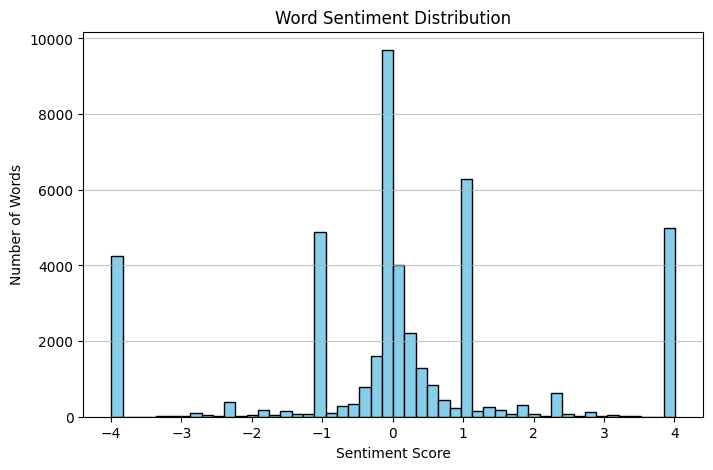

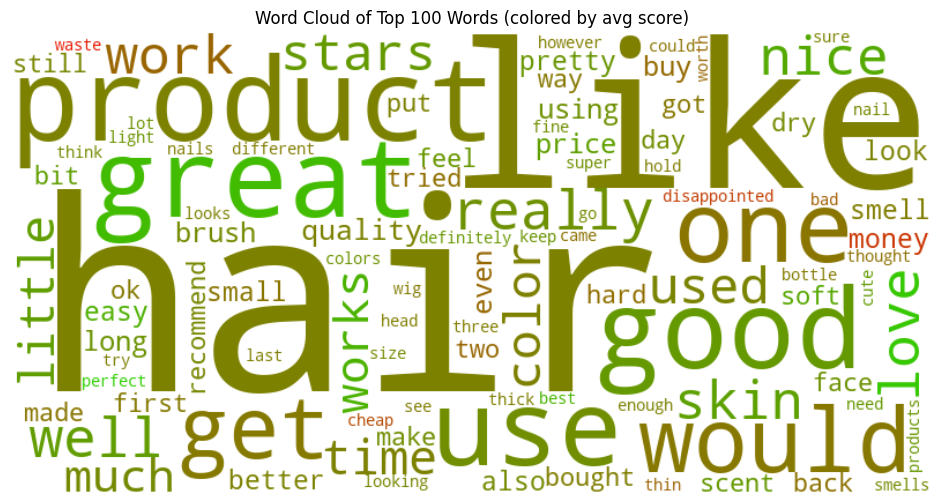

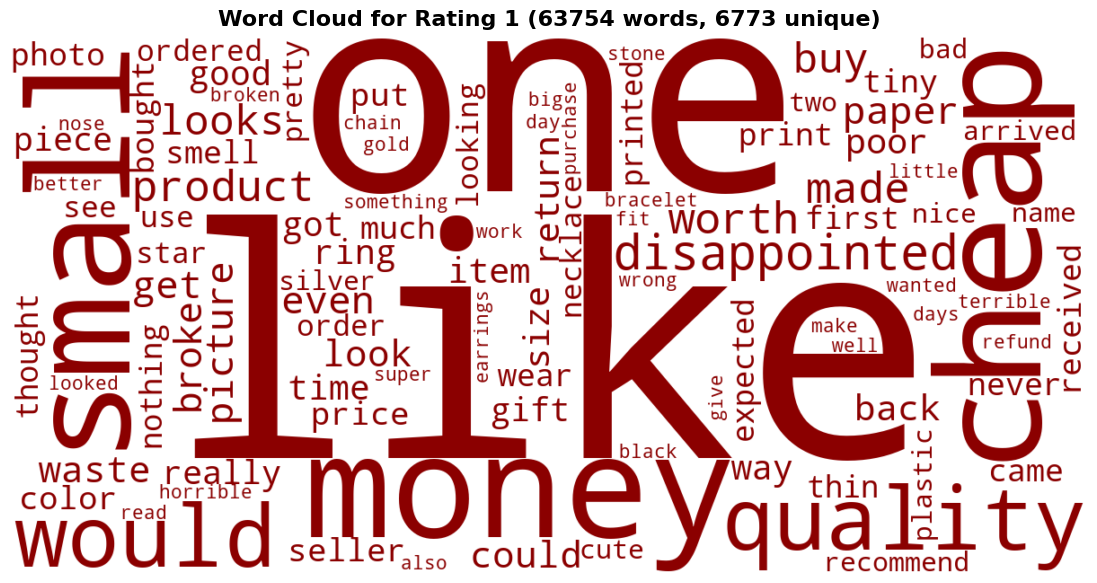

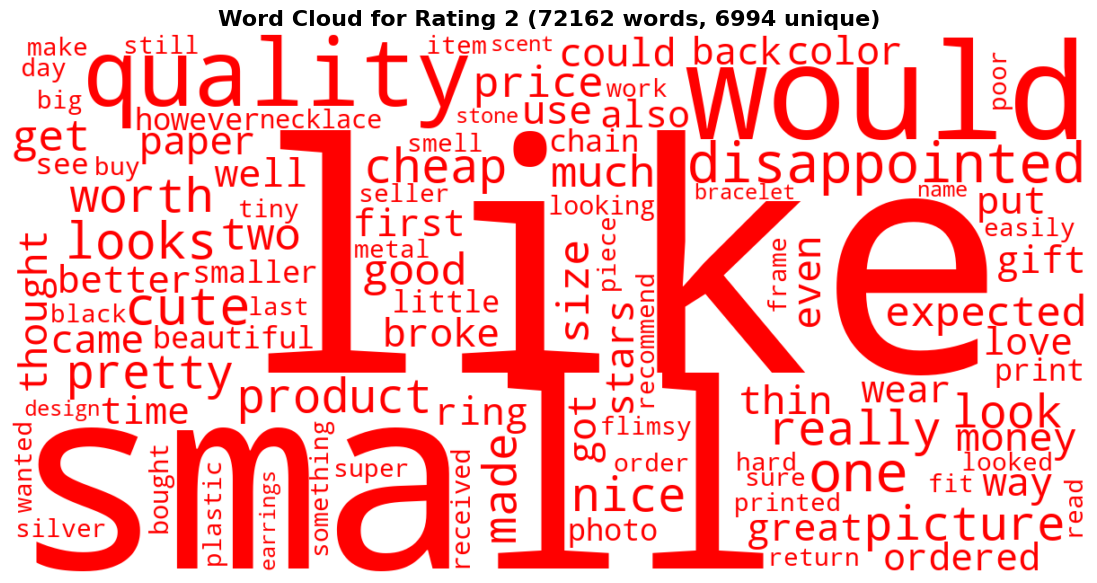

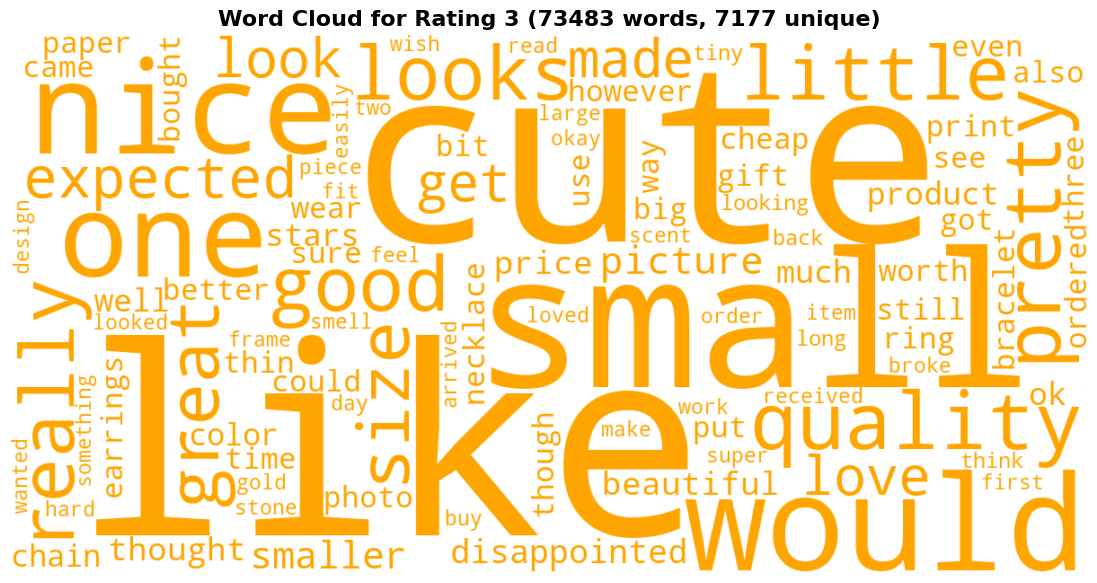

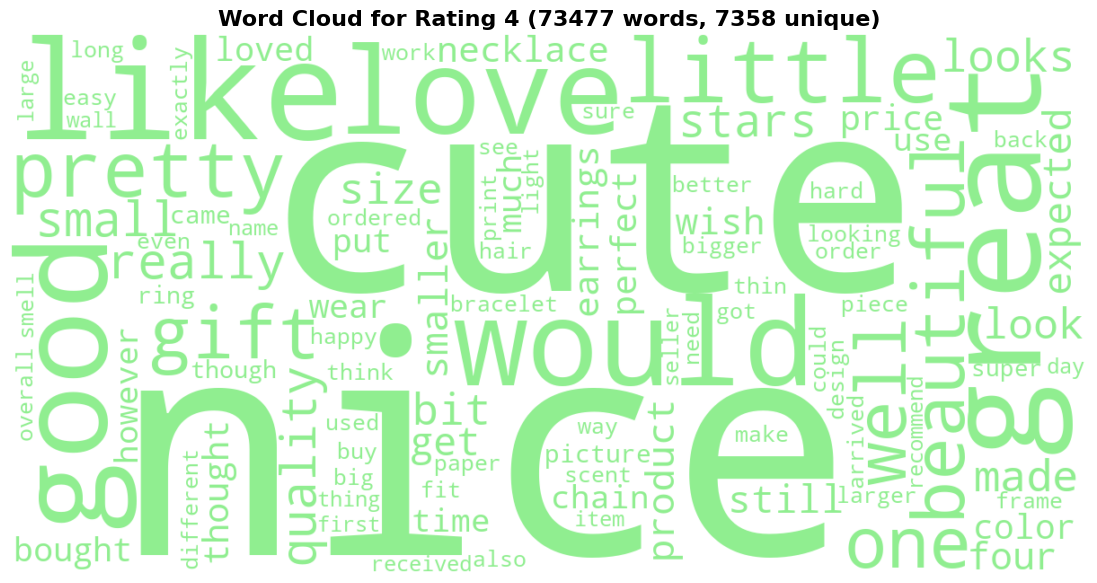

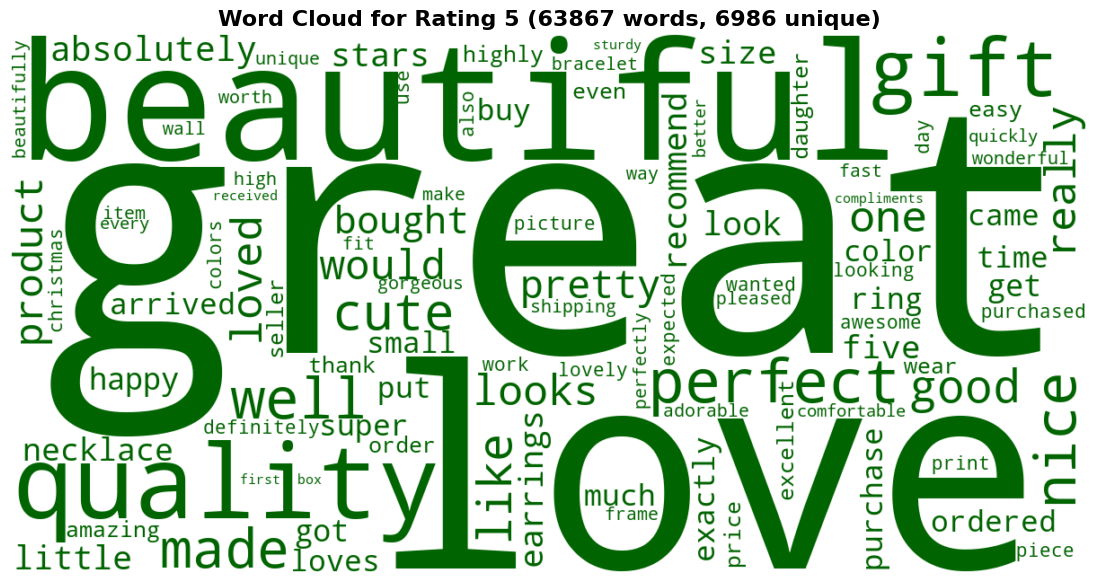

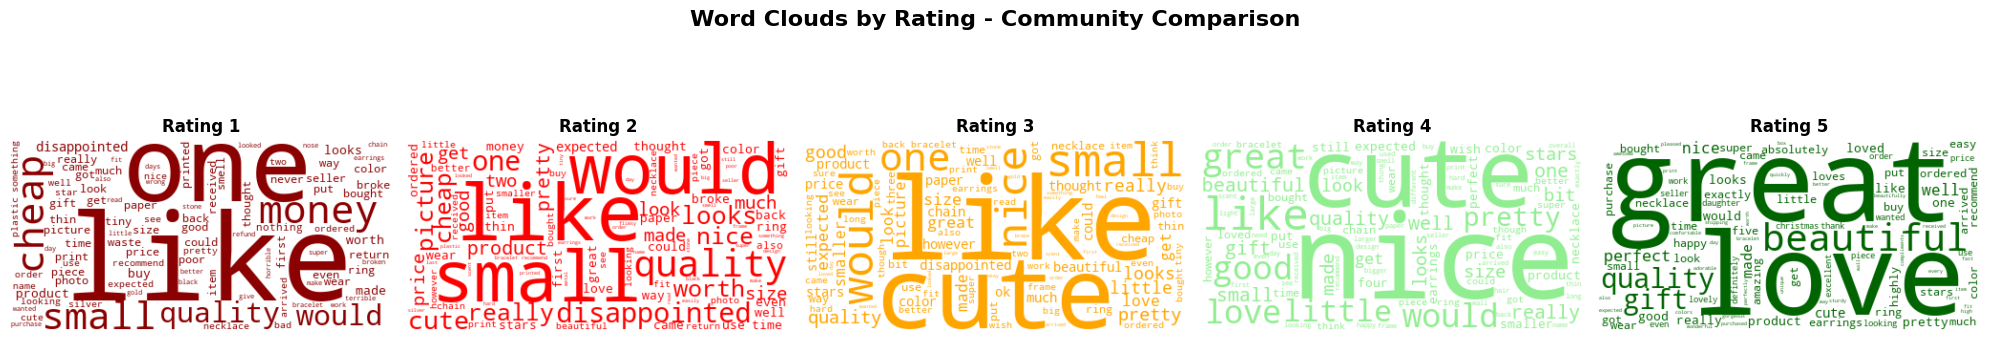

In [10]:
plot_word_sentiment_distribution(word_stats, bins=50)
plot_word_cloud(word_stats, top_words=100)
generate_rating_wordclouds(test_ds, prefix="", top_words=100)

Now we define more plotting functions to have some comparative basis for our different models:

In [23]:
def mse_plot(scores, mse_values, counts, savepath=None):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(scores, mse_values, width=0.4, color="skyblue", edgecolor="black")
    plt.xlabel("True Review Score")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.title("Word-Sentiment Reconstruction Error per Score")
    plt.grid(axis="y", alpha=0.7)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            "@" + str(count) + " rev's",
            ha="center",
            va="bottom",
            fontsize=10,
        )
    if savepath:
        plt.savefig(savepath)
    else:
        plt.show()


def confusion_plot(true_scores, pred_scores, savepath=None):
    all_scores = sorted(set([int(x) for x in true_scores]))
    confusion = pd.DataFrame(0, index=all_scores, columns=all_scores)

    for t, p in zip(true_scores, pred_scores):
        confusion.loc[t, round(p, 0)] += 1

    confusion_percent = confusion.div(confusion.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        confusion_percent,
        annot=True,
        fmt=".1f",
        cmap="viridis",
        cbar=True,
        xticklabels=all_scores,
        yticklabels=all_scores,
        vmin=0,
        vmax=60,
    )
    plt.xlabel("Predicted Score (rounded)")
    plt.ylabel("True Score")
    plt.title("Prediction Confusion Matrix (% per True Score)")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    else:
        plt.show()


def make_analysis(true_scores, pred_scores, prefix="", suffix=""):
    true_scores = np.array(true_scores)
    pred_scores = np.array(pred_scores)

    diff = np.abs(pred_scores - true_scores)
    mse = np.mean(np.where(diff >= 0.5, diff**2, 0))
    print(f"Overall MSE: {mse:.4f}")

    per_score_mse = defaultdict(list)
    per_score_count = defaultdict(int)
    for t, p in zip(true_scores, pred_scores):
        per_score_mse[t].append((p - t) ** 2)
        per_score_count[t] += 1

    scores = sorted(per_score_mse.keys())
    mse_values = [np.mean(per_score_mse[s]) for s in scores]
    counts = [per_score_count[s] for s in scores]

    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    mse_plot(
        scores,
        mse_values,
        counts,
        savepath=os.path.join(plots_dir, prefix + "ErrorPerScore_" + suffix + ".png"),
    )

    confusion_plot(
        true_scores,
        pred_scores,
        savepath=os.path.join(plots_dir, prefix + "ConfusionMatrix_" + suffix + ".png"),
    )
    return mse


Building the baseline was successful. Now, we should look at how it performs:

Running test: 100%|██████████| 20000/20000 [00:01<00:00, 16595.32it/s]


Overall MSE: 1.1194
Number of unknown words: 492


Running test: 100%|██████████| 20000/20000 [00:00<00:00, 24328.30it/s]


Overall MSE: 1.1606
Number of unknown words: 539


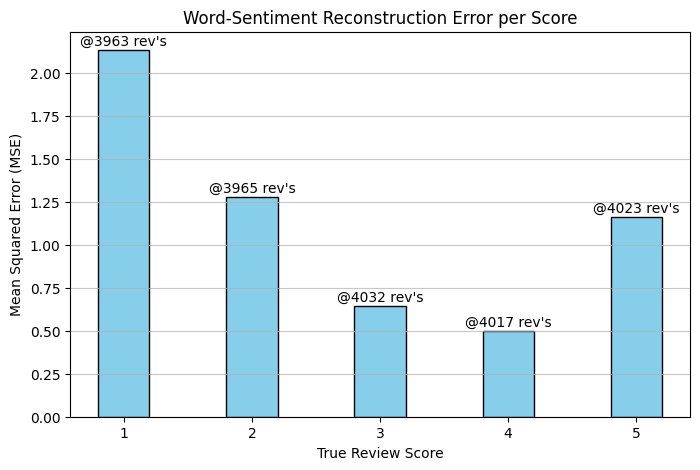

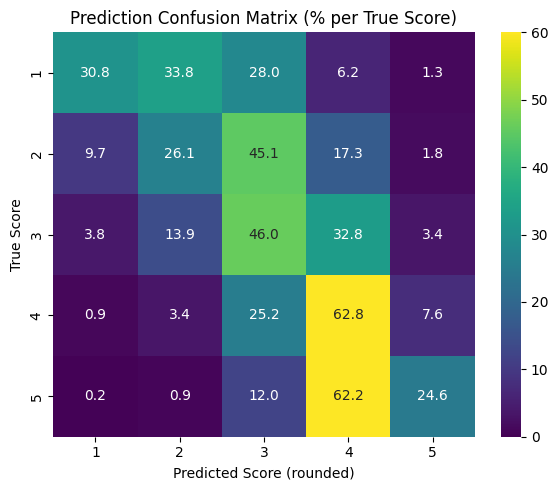

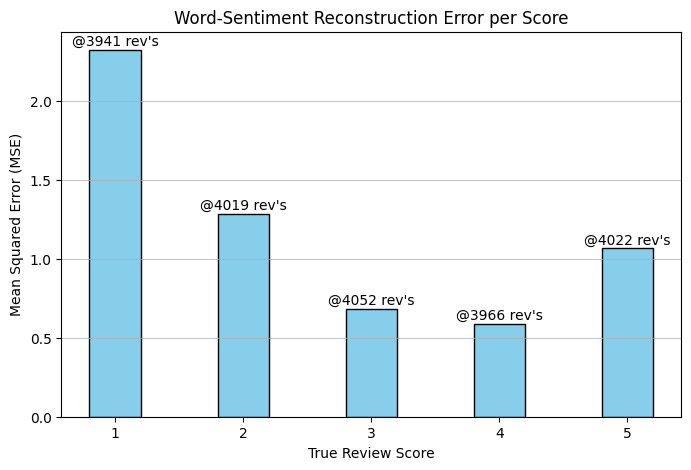

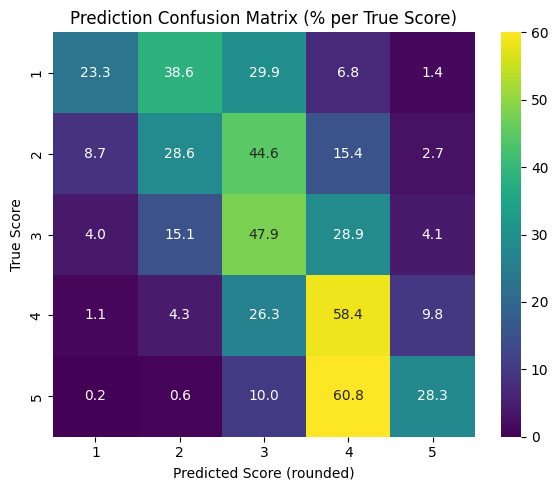

In [12]:
def evaluate_word_sentiment_reconstruction(
    dataset, word_stats, global_mean, global_std, prefix=""
):
    true_scores = []
    pred_scores = []
    n_unknown = 0

    for text, rating in tqdm(dataset, desc="Running test"):
        words = [w for w in re.findall(r"\b\w+\b", text.lower()) if w not in stop_words]
        word_sents = [
            word_stats[w]["sentiment"]
            for w in words
            if w in word_stats and abs(word_stats[w]["sentiment"]) > 0.3
        ]

        if word_sents:
            avg_sent = np.mean(word_sents)
            pred = global_mean + avg_sent * global_std
        else:
            pred = global_mean
            n_unknown += len([w for w in words if w not in word_stats])

        pred = max(1.0, min(5.0, pred))

        true_scores.append(rating)
        pred_scores.append(pred)

    make_analysis(true_scores, pred_scores, prefix=prefix, suffix="baseline")

    return n_unknown

unknown = evaluate_word_sentiment_reconstruction(
    val_ds, word_stats, global_mean, global_std
)
print("Number of unknown words:", unknown)

unknown = evaluate_word_sentiment_reconstruction(
    test_ds, word_stats, global_mean, global_std, prefix="Test_"
)
print("Number of unknown words:", unknown)

## TF-IDF

We are proposing a TF-IDF model using ridge or logistic vectorization as an improved baseline. Below is a from-scratch implementation of it:

With the constructive code out of the way, we move to training and testing the model. Since we implemented everything here in python, it will take a while...

Preprocessing training data...


Processing Train: 100%|██████████| 160000/160000 [00:04<00:00, 33878.47it/s]


Preprocessing validation data for tuning...


Processing Val: 100%|██████████| 20000/20000 [00:00<00:00, 31475.35it/s]


Vectorizing training texts...


...

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic C:  10.0 | Custom MSE: 1.0201
Best Logistic C: 1.0 (MSE: 0.9698)

--- Test Set Evaluation ---
Preprocessing Test_ data...


Processing reviews: 100%|██████████| 20000/20000 [00:00<00:00, 29434.35it/s]


Vectorizing texts...
Making predictions...
Overall MSE: 1.0032


array([5., 1., 1., ..., 3., 3., 1.])

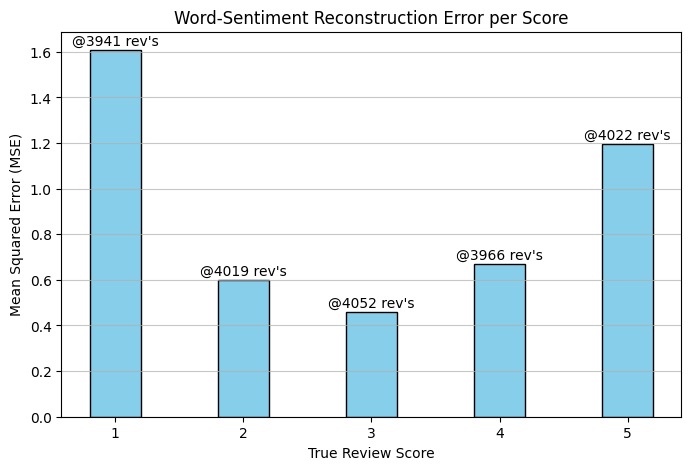

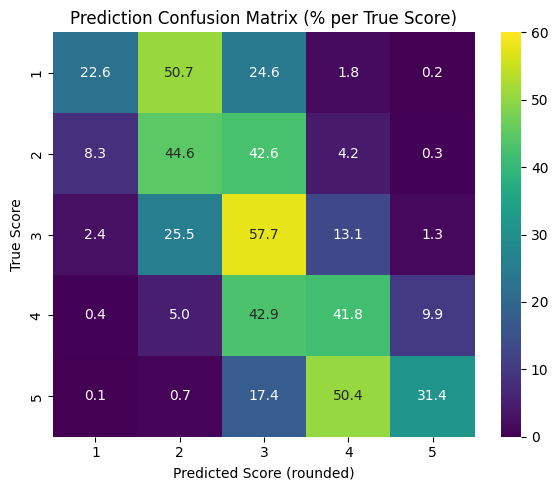

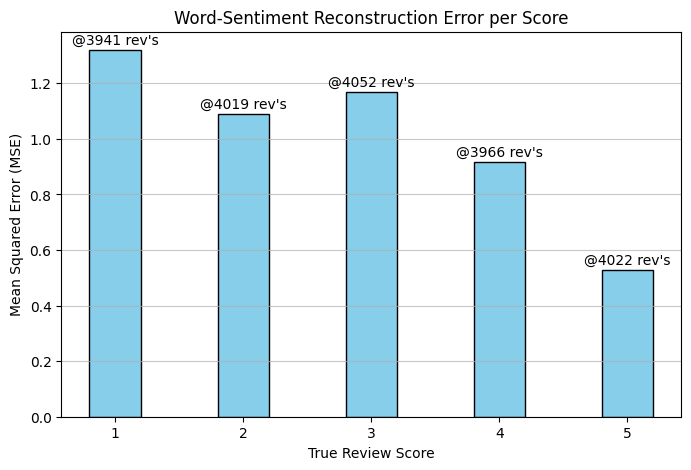

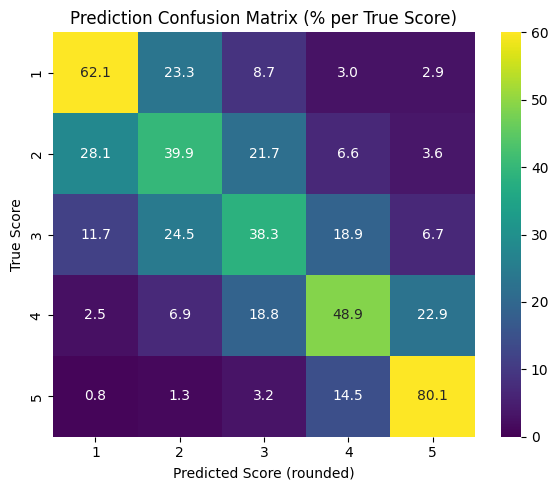

In [13]:
# --- Constants & Setup ---
WORD_PATTERN = re.compile(r"\b\w+\b")

# Download stopwords to ./nltk_data (if not already present)
nltk.download("stopwords", quiet=True)

# Load and update stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["br", "href", "http", "https", "www"]) 

# --- TF-IDF Class ---

class TfidfVectorizer:
    """
    TF-IDF Vectorizer implemented from scratch.
    Mimics scikit-learn's TfidfVectorizer interface.
    """

    def __init__(
        self,
        max_features=None,
        ngram_range=(1, 1),
        min_df=1,
        max_df=1.0,
        lowercase=True,
        strip_accents=None,
    ):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.lowercase = lowercase

        # Will be set during fit
        self.vocabulary_ = None
        self.idf_ = None
        self.feature_names_ = None
    
    def _generate_ngrams(self, tokens):
        """Generate n-grams from a list of tokens."""
        min_n, max_n = self.ngram_range
        n_tokens = len(tokens)

        for n in range(min_n, max_n + 1):
            if n_tokens < n:
                continue
            for i in range(n_tokens - n + 1):
                yield tuple(tokens[i:i+n])

    def _tokenize(self, text):
        """Tokenize text into words."""
        if self.lowercase:
            text = text.lower()

        # Extract words using regex
        words = WORD_PATTERN.findall(text)

        # Filter stopwords and short words
        sw = stop_words
        tokens = [
            w for w in words if w not in sw and len(w) > 1 and w.isalpha()
        ]

        return tokens

    def _build_vocabulary(self, documents):
        """Build vocabulary from documents."""
        # Count document frequencies for each n-gram
        doc_freq = Counter()
        n_docs = len(documents)
        tokenized_docs = []
        ngram_docs = []
        
        for doc in tqdm(documents, desc="Building vocabulary"):
            tokens = self._tokenize(doc)
            tokenized_docs.append(tokens)
        
            ngrams = list(self._generate_ngrams(tokens))
            ngram_docs.append(ngrams)
        
            doc_freq.update(set(ngrams))

        # Filter by min_df and max_df
        min_doc_freq = (
            self.min_df if isinstance(self.min_df, int) else int(self.min_df * n_docs)
        )
        max_doc_freq = (
            self.max_df if isinstance(self.max_df, int) else int(self.max_df * n_docs)
        )

        # Filter vocabulary
        filtered_vocab = {
            ngram: freq
            for ngram, freq in doc_freq.items()
            if min_doc_freq <= freq <= max_doc_freq
        }

        # Select top features if max_features is specified
        if self.max_features and len(filtered_vocab) > self.max_features:
            # Sort by frequency (descending) and take top max_features
            sorted_vocab = sorted(
                filtered_vocab.items(), key=lambda x: x[1], reverse=True
            )[: self.max_features]
            filtered_vocab = dict(sorted_vocab)

        # Create vocabulary mapping (ngram -> index)
        sorted_ngrams = sorted(filtered_vocab.keys())
        self.vocabulary_ = {ngram: idx for idx, ngram in enumerate(sorted_ngrams)}
        self.feature_names_ = [self._ngram_to_string(ngram) for ngram in sorted_ngrams]

        # Calculate IDF for each term
        df_array = np.array([doc_freq[ng] for ng in sorted_ngrams])
        self.idf_ = np.log((n_docs + 1) / (df_array + 1)) + 1

    def _ngram_to_string(self, ngram):
        """Convert n-gram tuple to string representation."""
        if isinstance(ngram, tuple):
            return " ".join(ngram)
        return ngram

    def _compute_tfidf(self, ngrams):
        """compute tf-idf using sparse dict."""
        vocab = self.vocabulary_
        idf = self.idf_

        tf_counts = Counter(ngrams)
        total = len(ngrams)

        if total == 0:
            return np.zeros(len(vocab))

        # sparse row
        row = {}
        norm_factor = 1.0 / total

        for ng, count in tf_counts.items():
            idx = vocab.get(ng)
            if idx is not None:
                row[idx] = (count * norm_factor) * idf[idx]

        # convert sparse dict to dense vector
        vec = np.zeros(len(vocab))
        for idx, val in row.items():
            vec[idx] = val

        return vec


    def fit(self, raw_documents):
        self._build_vocabulary(raw_documents)
        return self
    

    def transform(self, raw_documents):
        if self.vocabulary_ is None:
            raise ValueError("Vectorizer has not been fitted yet. Call fit() first.")

        n_docs = len(raw_documents)
        n_features = len(self.vocabulary_)
        tfidf_matrix = np.zeros((n_docs, n_features))

        for i, doc in enumerate(raw_documents):
            tokens = self._tokenize(doc)
            ngrams = list(self._generate_ngrams(tokens))
            tfidf_matrix[i] = self._compute_tfidf(ngrams)

        return tfidf_matrix


    def fit_transform(self, raw_documents):
        self.fit(raw_documents)
        return self.transform(raw_documents)

# --- Helper Functions ---

def preprocess_text(text):
    words = [
        x.lower()
        for x in WORD_PATTERN.findall(text.lower())
        if x.lower() not in stop_words and len(x) > 1 and x.isalpha()
    ]
    return " ".join(words)


# Re-using the same imports and setup from previous cells
# (Assuming TfidfVectorizer class and helper functions are already defined)

def train_and_tune_tfidf_model(train_ds, val_ds, method="ridge", max_features=5000, ngram_range=(1, 2)):
    # --- Prepare Training Data ---
    train_texts = []
    train_ratings = []
    print("Preprocessing training data...")
    for text, rating in tqdm(train_ds, desc="Processing Train"):
        train_texts.append(preprocess_text(text))
        train_ratings.append(rating)
    train_ratings = np.array(train_ratings)

    # --- Prepare Validation Data ---
    val_texts = []
    val_ratings = []
    print("Preprocessing validation data for tuning...")
    for text, rating in tqdm(val_ds, desc="Processing Val"):
        val_texts.append(preprocess_text(text))
        val_ratings.append(rating)
    val_ratings = np.array(val_ratings)

    # --- Vectorization ---
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95,
        lowercase=True,
        strip_accents="unicode",
    )

    print("Vectorizing training texts...")
    X_train = vectorizer.fit_transform(train_texts)
    print("Vectorizing validation texts...")
    X_val = vectorizer.transform(val_texts)

    print(f"TF-IDF matrix shape: {X_train.shape}")
    
    # Convert to sparse matrix
    X_train = csr_matrix(X_train)
    X_val = csr_matrix(X_val)

    best_model = None

    if method == "ridge":
        print("Tuning Ridge Regression (finding best alpha)...")
        alphas = [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
        best_mse = float('inf')
        best_alpha = None

        for alpha in alphas:
            model = Ridge(alpha=alpha, random_state=42)
            model.fit(X_train, train_ratings)
            
            val_preds = model.predict(X_val)
            val_preds = np.clip(val_preds, 1.0, 5.0)
            
            # Custom MSE
            diff = np.abs(val_ratings - val_preds)
            mse = np.mean(np.where(diff >= 0.5, diff**2, 0))
            
            print(f"Ridge Alpha: {alpha:>6} | Custom MSE: {mse:.4f}")

            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
                best_model = model
        
        print(f"Best Ridge Alpha: {best_alpha} (MSE: {best_mse:.4f})")

    elif method == "logistic":
        print("Tuning Logistic Regression (finding best C)...")
        # Note: Logistic Regression requires integer labels for classification
        train_ratings_int = train_ratings.astype(int)
        
        # Hyperparameters to test (C is Inverse Regularization Strength)
        # Smaller C = Stronger Regularization
        Cs = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
        best_mse = float('inf')
        best_C = None

        for C in Cs:
            model = LogisticRegression(
                C=C,
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=1000, # Increased max_iter for convergence
                random_state=42,
            )
            model.fit(X_train, train_ratings_int)
            
            # Predict (Outputs class labels 1, 2, 3, 4, 5 directly)
            val_preds = model.predict(X_val)
            
            # Custom MSE logic applies even to classification labels
            diff = np.abs(val_ratings - val_preds)
            mse = np.mean(np.where(diff >= 0.5, diff**2, 0))
            
            print(f"Logistic C: {C:>5} | Custom MSE: {mse:.4f}")

            if mse < best_mse:
                best_mse = mse
                best_C = C
                best_model = model
        
        print(f"Best Logistic C: {best_C} (MSE: {best_mse:.4f})")

    else:
        raise ValueError(f"Unknown method: {method}. Use 'ridge' or 'logistic'")

    return vectorizer, best_model, method

def predict_tfidf(dataset, vectorizer, model, method, prefix=""):
    texts = []
    true_scores = []

    print(f"Preprocessing {prefix} data...")
    for text, rating in tqdm(dataset, desc="Processing reviews"):
        texts.append(preprocess_text(text))
        true_scores.append(rating)

    print("Vectorizing texts...")
    X_test = vectorizer.transform(texts)

    print("Making predictions...")
    pred_scores = model.predict(X_test)

    pred_scores = np.clip(pred_scores, 1.0, 5.0)
    true_scores = np.array(true_scores)

    suffix = f"tfidf_{method}"
    
    if 'make_analysis' in globals():
        make_analysis(true_scores, pred_scores, prefix=prefix, suffix=suffix)
    else:
        print("Warning: 'make_analysis' function not found in globals. Skipping plot generation.")

    return pred_scores


# 1. Train and Tune (using val_ds for hyperparameter tuning with Custom MSE)
vectorizer_ridge, model_ridge, _ = train_and_tune_tfidf_model(
    train_ds, 
    val_ds, 
    method="ridge", 
    max_features=10000, 
    ngram_range=(1, 2)
)

# 2. Final Evaluation on Test Set
predict_tfidf(test_ds, vectorizer_ridge, model_ridge, "ridge", prefix="Test_")

# 3. Train and Tune Logistic Regression
vectorizer_log, model_log, _ = train_and_tune_tfidf_model(
    train_ds, 
    val_ds, # We use val_ds to find the best 'C'
    method="logistic", 
    max_features=10000, 
    ngram_range=(1, 2)
)

# 4. Final Evaluation on Test Set
print("\n--- Test Set Evaluation ---")
predict_tfidf(test_ds, vectorizer_log, model_log, "logistic", prefix="Test_")

## LSH

We implement locality-sensitive hashing to find out if it can capture similarities well enough to be suitable for prediction.

=== TUNING LSH ===
Loading signatures from ./cache/lsh_train_sigs.npz...
Loading signatures from ./cache/lsh_val_sigs.npz...

Grid Search: Bands=[20, 50, 100], Top_K=[1, 5, 10, 20]

--- Testing Bands=20 (Threshold ~ 0.74) ---
   [bands=20, k=1] -> MSE: 1.8860
   *** New Best! ***
   [bands=20, k=5] -> MSE: 1.8756
   *** New Best! ***
   [bands=20, k=10] -> MSE: 1.8754
   *** New Best! ***
   [bands=20, k=20] -> MSE: 1.8753
   *** New Best! ***

--- Testing Bands=50 (Threshold ~ 0.38) ---
   [bands=50, k=1] -> MSE: 2.1892
   [bands=50, k=5] -> MSE: 1.2878
   *** New Best! ***
   [bands=50, k=10] -> MSE: 1.2073
   *** New Best! ***
   [bands=50, k=20] -> MSE: 1.1976
   *** New Best! ***

--- Testing Bands=100 (Threshold ~ 0.10) ---
   [bands=100, k=1] -> MSE: 2.0351
   [bands=100, k=5] -> MSE: 1.1749
   *** New Best! ***
   [bands=100, k=10] -> MSE: 1.0825
   *** New Best! ***
   [bands=100, k=20] -> MSE: 1.0474
   *** New Best! ***

=== TUNING COMPLETE ===
Best Config: bands=100, top_k=

Predicting: 100%|██████████| 20000/20000 [10:40<00:00, 31.23it/s]


Overall MSE: 1.0447


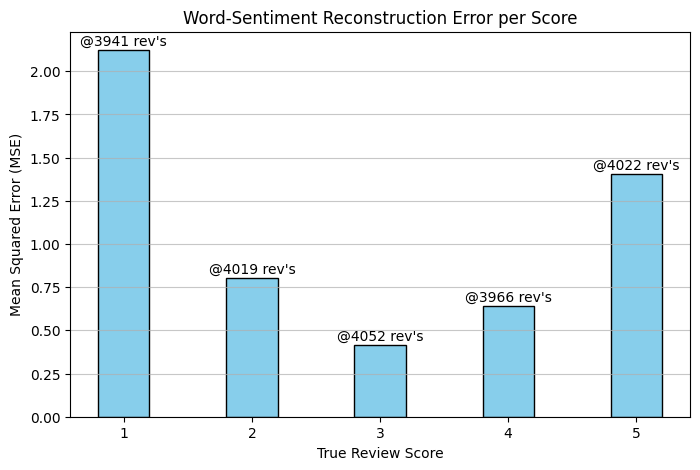

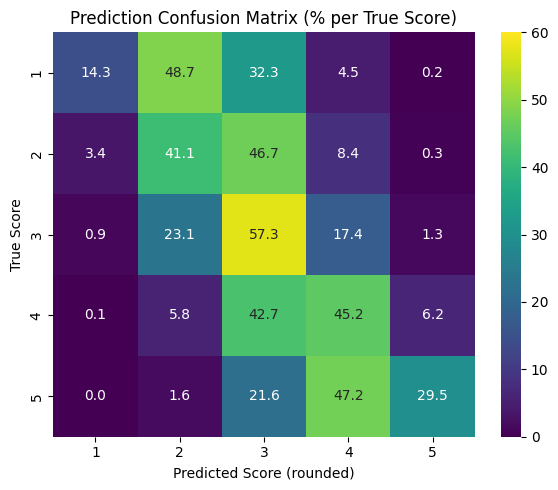

In [16]:
# --- 1. Core Classes ---

def get_shingles(text, q=3):
    word_pattern = re.compile(r"\b\w+\b")
    # Optimize: Pre-compile regex and use set comprehension directly
    tokens = [x for x in word_pattern.findall(text.lower()) if x not in stop_words]
    text_joined = "_".join(tokens)
    return {text_joined[i : i + q] for i in range(max(0, len(text_joined) - q + 1))}

class MinHash:
    def __init__(self, num_hashes=200, seed=42): # Increased default to 200 for better divisibility
        self.num_hashes = num_hashes
        self.seed = seed
        self.large_prime = (1 << 61) - 1
        rng = np.random.default_rng(seed)
        self.a = rng.integers(1, self.large_prime, size=num_hashes, dtype=np.uint64)
        self.b = rng.integers(0, self.large_prime, size=num_hashes, dtype=np.uint64)

    def signature(self, shingles):
        if not shingles:
            return np.zeros(self.num_hashes, dtype=np.uint64)
        
        # Vectorized hashing for speed
        shingle_bytes = [s.encode() for s in shingles]
        # MD5 is slow, but fine for now. MurmurHash3 is faster if you have mmh3 library.
        hashes_raw = [int(hashlib.md5(b).hexdigest(), 16) & ((1 << 64) - 1) for b in shingle_bytes]
        shingle_hashes = np.array(hashes_raw, dtype=np.uint64)
        
        # MinHash vectorization
        # shape: (num_hashes, num_shingles)
        combined = (np.outer(self.a, shingle_hashes) + self.b[:, None]) % self.large_prime
        return combined.min(axis=1)

class LSHIndex:
    def __init__(self, num_hashes=200, bands=50):
        self.num_hashes = num_hashes
        self.bands = bands
        self.rows = num_hashes // bands
        self.tables = [defaultdict(list) for _ in range(bands)]
        self.signatures = []
        self.labels = []
        # Pre-compute byte conversions for speed
        self._signatures_bytes = [] 

    def add_bulk(self, signatures, labels):
        """Optimized bulk addition."""
        start_idx = len(self.signatures)
        self.signatures.extend(signatures)
        self.labels.extend(labels)
        
        for i, sig in enumerate(signatures):
            idx = start_idx + i
            # Hashing bands
            for b in range(self.bands):
                start = b * self.rows
                end = (b + 1) * self.rows
                # We hash the slice of the numpy array
                band_hash = hash(sig[start:end].tobytes()) # Python's built-in hash is faster than md5 here
                self.tables[b][band_hash].append(idx)

    def predict_label(self, signature, top_k=5):
        candidates = set()
        for b in range(self.bands):
            start = b * self.rows
            end = (b + 1) * self.rows
            band_hash = hash(signature[start:end].tobytes())
            candidates.update(self.tables[b].get(band_hash, []))

        if not candidates:
            return None

        # Jaccard estimation via signature comparison
        # Only compare against candidates
        candidate_list = list(candidates)
        candidate_sigs = np.array([self.signatures[i] for i in candidate_list])
        
        # Vectorized comparison: (matches / num_hashes)
        matches = (candidate_sigs == signature)
        sims = np.mean(matches, axis=1)
        
        # Sort top K
        sorted_indices = np.argsort(-sims)[:top_k]
        top_sims = sims[sorted_indices]
        top_labels = np.array([self.labels[candidate_list[i]] for i in sorted_indices])

        # Weighted Average
        total_sim = np.sum(top_sims)
        if total_sim == 0:
            return np.mean(top_labels)
        
        return np.sum(top_sims * top_labels) / total_sim


# --- 2. Tuning & Training Logic ---

def compute_signatures_once(dataset, num_hashes=200, cache_path=None):
    """Computes MinHash signatures once and caches them."""
    if cache_path and os.path.exists(cache_path):
        print(f"Loading signatures from {cache_path}...")
        data = np.load(cache_path, allow_pickle=True)
        return data['sigs'], data['labels']

    print("Computing MinHash signatures (this is slow)...")
    minhash = MinHash(num_hashes=num_hashes)
    sig_list = []
    rat_list = []

    for text, rating in tqdm(dataset, desc="Hashing"):
        shingles = get_shingles(text, q=3) # Fixed q=3
        if not shingles:
            # Handle empty docs by creating a zero signature or skipping
            # Ideally skip or add special token, here we add a zero-sig placeholder
            sig = np.zeros(num_hashes, dtype=np.uint64)
        else:
            sig = minhash.signature(shingles)
        
        sig_list.append(sig)
        rat_list.append(rating)

    sigs = np.array(sig_list)
    labels = np.array(rat_list)

    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        np.savez(cache_path, sigs=sigs, labels=labels)
        
    return sigs, labels

def tune_lsh(train_ds, val_ds, num_hashes=200):
    print("=== TUNING LSH ===")
    
    # 1. Prepare Data (One-time cost)
    project_root = globals().get("PROJECT_ROOT", ".")
    cache_dir = os.path.join(project_root, "cache")
    
    train_sigs, train_labels = compute_signatures_once(
        train_ds, num_hashes, os.path.join(cache_dir, "lsh_train_sigs.npz")
    )
    val_sigs, val_labels = compute_signatures_once(
        val_ds, num_hashes, os.path.join(cache_dir, "lsh_val_sigs.npz")
    )

    # 2. Grid Search (Fast)
    # Bands must be divisors of num_hashes (200)
    # 200 divisors: 10, 20, 25, 40, 50, 100
    bands_options = [20, 50, 100] 
    top_k_options = [1, 5, 10, 20]

    best_mse = float('inf')
    best_config = (50, 5) # Default
    
    print(f"\nGrid Search: Bands={bands_options}, Top_K={top_k_options}")

    for b in bands_options:
        rows = num_hashes // b
        threshold = (1/b)**(1/rows)
        print(f"\n--- Testing Bands={b} (Threshold ~ {threshold:.2f}) ---")
        
        # Build Index
        lsh = LSHIndex(num_hashes=num_hashes, bands=b)
        lsh.add_bulk(list(train_sigs), list(train_labels))

        # We can reuse the same index for all top_k values
        # Predict on Validation
        for k in top_k_options:
            preds = []
            
            # Predict loop
            for sig in val_sigs:
                p = lsh.predict_label(sig, top_k=k)
                if p is None: p = 3.0 # Default if no neighbors
                preds.append(p)
            
            preds = np.array(preds)
            
            # Custom MSE
            diff = np.abs(val_labels - preds)
            mse = np.mean(np.where(diff >= 0.5, diff**2, 0))
            
            print(f"   [bands={b}, k={k}] -> MSE: {mse:.4f}")
            
            if mse < best_mse:
                best_mse = mse
                best_config = (b, k)
                print("   *** New Best! ***")

    print("\n=== TUNING COMPLETE ===")
    print(f"Best Config: bands={best_config[0]}, top_k={best_config[1]} (MSE: {best_mse:.4f})")
    
    # Return the best index trained on full data (already done in loop actually)
    # But let's return a fresh one to be clean
    best_lsh = LSHIndex(num_hashes=num_hashes, bands=best_config[0])
    best_lsh.add_bulk(list(train_sigs), list(train_labels))
    best_minhash = MinHash(num_hashes=num_hashes) # Helper for inference
    
    return best_lsh, best_minhash, best_config

def lsh_predict_test(dataset, lsh, minhash, top_k, prefix=""):
    print(f"\nRunning LSH Prediction on {prefix} set (top_k={top_k})...")
    true_scores = []
    pred_scores = []
    
    for text, rating in tqdm(dataset, desc="Predicting"):
        shingles = get_shingles(text, q=3)
        if not shingles:
            pred = 3.0
        else:
            sig = minhash.signature(shingles)
            pred = lsh.predict_label(sig, top_k=top_k)
            if pred is None: pred = 3.0
            
        true_scores.append(rating)
        pred_scores.append(pred)
        
    if 'make_analysis' in globals():
        make_analysis(true_scores, pred_scores, prefix=prefix, suffix="lsh")


# --- EXECUTION ---

# 1. Tune LSH
# We use num_hashes=200 to allow flexible band splitting (200 has many divisors)
best_lsh, best_minhash, best_params = tune_lsh(train_ds, val_ds, num_hashes=200)

# 2. Predict
lsh_predict_test(test_ds, best_lsh, best_minhash, top_k=best_params[1], prefix="Test_")

## Clustering

Performance of LSH did not impress. Instead, we will now look into clustering. Since we are working with large datasets, we implement MiniBatchKMeans.

=== STARTING CLUSTERING TUNING (OPTIMIZED) ===

[Phase 1] Encoding Training Data...
   -> Loading training embeddings from ./cache/train_embeddings_full.npy...

[Phase 1] Encoding Validation Data...

[Phase 2] Grid Search (K=[20, 50, 100, 250, 500], X=[1, 5, 10, 25, 50])
      > New Best! [clusters k=20, num_closest_clusters x=1] MSE: 1.7274
      > New Best! [clusters k=20, num_closest_clusters x=5] MSE: 0.9311
                  [clusters k=20, num_closest_clusters x=10] MSE: 0.9622
                  [clusters k=50, num_closest_clusters x=1] MSE: 1.5808
                  [clusters k=50, num_closest_clusters x=5] MSE: 0.9651
      > New Best! [clusters k=50, num_closest_clusters x=10] MSE: 0.8767
                  [clusters k=50, num_closest_clusters x=25] MSE: 0.9627
                  [clusters k=100, num_closest_clusters x=1] MSE: 1.6591
                  [clusters k=100, num_closest_clusters x=5] MSE: 1.0126
                  [clusters k=100, num_closest_clusters x=10] MSE: 0.9055
 

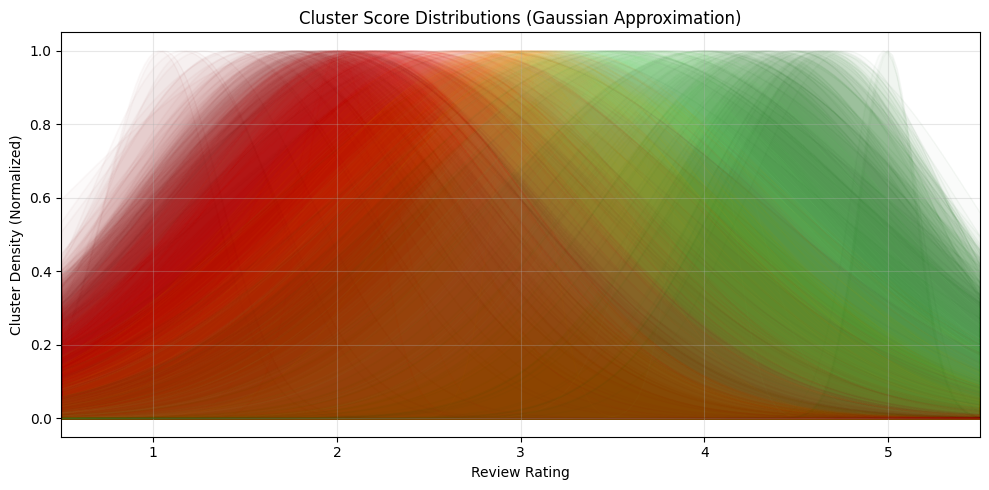


[Prediction] Starting prediction on Test_ set (k=250, x=50)...
Overall MSE: 0.8539


0

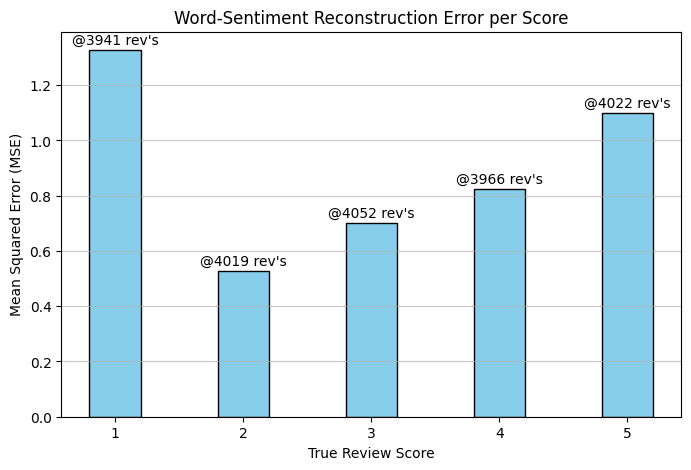

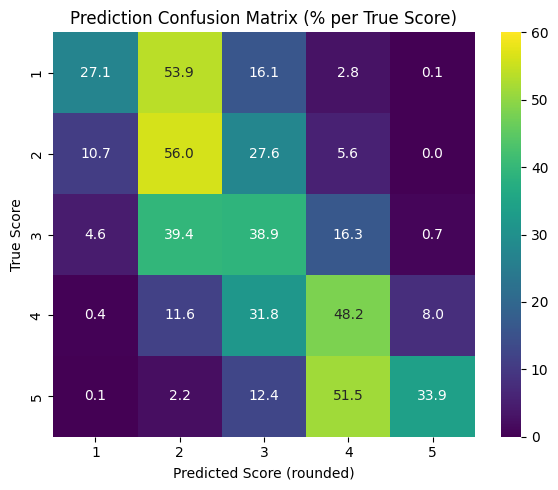

In [20]:
class MiniBatchKMeans:
    def __init__(self, n_clusters=8, batch_size=256, max_iter=100, random_state=None):
        self.n_clusters = n_clusters
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.random_state = np.random.RandomState(random_state)
        self.cluster_centers_ = None

    def _init_centers(self, X):
        idx = self.random_state.choice(len(X), self.n_clusters, replace=False)
        centers = X[idx].astype(np.float64)
        centers /= np.linalg.norm(centers, axis=1, keepdims=True) + 1e-12
        return centers

    def _closest_center(self, X, centers):
        sims = np.dot(X, centers.T)
        return np.argmax(sims, axis=1)

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.cluster_centers_ is None:
            self.cluster_centers_ = self._init_centers(X)
        counts = np.zeros(self.n_clusters, dtype=np.int64)

        for _ in range(self.max_iter):
            idx = self.random_state.choice(len(X), self.batch_size, replace=False)
            batch = X[idx]
            labels = self._closest_center(batch, self.cluster_centers_)
            for i, x in zip(labels, batch):
                counts[i] += 1
                eta = 1.0 / counts[i]
                self.cluster_centers_[i] = (1 - eta) * self.cluster_centers_[i] + eta * x
                self.cluster_centers_[i] /= (np.linalg.norm(self.cluster_centers_[i]) + 1e-12)
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self._closest_center(X, self.cluster_centers_)

def plot_cluster_spread(stats, savepath=None):
    plt.figure(figsize=(10, 5))
    x = np.linspace(0.5, 5.5, 200)
    
    colors = {1: "darkred", 2: "red", 3: "orange", 4: "lightgreen", 5: "darkgreen"}
    
    if not stats:
        print("No cluster stats to plot.")
        return

    print(f"   [Plotting] Generating curves for {len(stats)} clusters...")
    
    for mean, std, rating in stats:
        # Handle zero variance for visualization
        safe_std = max(std, 0.15) 
        y = norm.pdf(x, mean, safe_std)
        if np.max(y) > 0:
            y = y / np.max(y) 
            
        plt.plot(x, y, alpha=5/len(stats), linewidth=1, color=colors.get(int(rating), "grey"))
        plt.fill_between(x, y, alpha=5/len(stats), color=colors.get(int(rating), "grey"))
        
    plt.xlabel("Review Rating")
    plt.ylabel("Cluster Density (Normalized)")
    plt.title("Cluster Score Distributions (Gaussian Approximation)")
    plt.grid(True, alpha=0.3)
    plt.xlim(0.5, 5.5)
    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=150)
        print(f"   [Plot] Saved to {savepath}")
    
    plt.show() 

def transformer_kmeans_clustering(embeddings, ratings, k=50):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=3072)
    clusters = kmeans.fit_predict(embeddings)
    
    cluster_ratings = {}
    cluster_stats = []
    
    for i in range(k):
        current_cluster_ratings = ratings[clusters == i]
        if len(current_cluster_ratings) == 0:
            cluster_ratings[i] = 3.0
            continue

        cluster_ratings[i] = np.bincount(current_cluster_ratings.astype(int)).argmax()
        cluster_stats.append((
            np.mean(current_cluster_ratings),
            np.std(current_cluster_ratings),
            cluster_ratings[i],
        ))

    return kmeans, cluster_ratings, cluster_stats

# Tuning function to get best parameters
def train_and_tune_clustering(train_ds, val_ds, model, tokenizer):
    print("=== STARTING CLUSTERING TUNING (OPTIMIZED) ===")
    
    project_root = globals().get("PROJECT_ROOT", ".")
    cache_dir = os.path.join(project_root, "cache")
    plots_dir = os.path.join(project_root, "plots")
    os.makedirs(cache_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)
    
    # A. Encode Training Data
    print("\n[Phase 1] Encoding Training Data...")
    train_cache_path = os.path.join(cache_dir, "train_embeddings_full.npy")
    train_ratings = np.array([r for _, r in train_ds])

    if os.path.exists(train_cache_path):
        print(f"   -> Loading training embeddings from {train_cache_path}...")
        train_embeddings = np.load(train_cache_path)
    else:
        print("   -> Computing training embeddings (this happens only once)...")
        train_texts = [t for t, _ in train_ds]
        train_embeddings = encode_texts(model, tokenizer, train_texts)
        train_embeddings = normalize(train_embeddings, norm="l2", axis=1)
        np.save(train_cache_path, train_embeddings)
        
    # B. Encode Validation Data
    print("\n[Phase 1] Encoding Validation Data...")
    val_texts = [t for t, _ in val_ds]
    val_ratings = np.array([r for _, r in val_ds])
    val_embeddings = encode_texts(model, tokenizer, val_texts)
    val_embeddings = normalize(val_embeddings, norm="l2", axis=1)

    # --- PHASE 2: GRID SEARCH ---
    k_values = [20, 50, 100, 250, 500]
    x_values = [1, 5, 10, 25, 50]

    best_mse = float('inf')
    best_config = (50, 15)
    best_kmeans = None
    best_cluster_ratings = None
    best_cluster_stats = None

    print(f"\n[Phase 2] Grid Search (K={k_values}, X={x_values})")

    for k in k_values:
        # print(f"\n--- Testing Cluster Count k={k} ---")
        
        kmeans, cluster_ratings_map, cluster_stats = transformer_kmeans_clustering(
            train_embeddings, train_ratings, k=k
        )

        centers = normalize(kmeans.cluster_centers_, norm="l2", axis=1)
        cluster_scores = np.array([cluster_ratings_map.get(i, 3.0) for i in range(k)])

        dists = cdist(val_embeddings, centers, metric="euclidean")

        for x in x_values:
            if x >= k: continue

            nearest_indices = np.argsort(dists, axis=1)[:, :x]
            nearest_dists = np.take_along_axis(dists, nearest_indices, axis=1)

            weights = 1.0 / (nearest_dists + 1e-8)
            weights_sum = weights.sum(axis=1, keepdims=True)
            weights = weights / weights_sum

            nearest_scores = cluster_scores[nearest_indices]
            pred_scores = np.sum(nearest_scores * weights, axis=1)

            diff = np.abs(val_ratings - pred_scores)
            mse = np.mean(np.where(diff >= 0.5, diff**2, 0))

            if mse < best_mse:
                print(f"      > New Best! [clusters k={k}, num_closest_clusters x={x}] MSE: {mse:.4f}")
                best_mse = mse
                best_config = (k, x)
                best_kmeans = kmeans
                best_cluster_ratings = cluster_ratings_map
                best_cluster_stats = cluster_stats
            else:
                print(f"                  [clusters k={k}, num_closest_clusters x={x}] MSE: {mse:.4f}")

    print("\n=== TUNING COMPLETE ===")
    print(f"Best Configuration: k={best_config[0]}, x={best_config[1]} (MSE: {best_mse:.4f})")
    
    # --- PHASE 3: PLOT BEST DISTRIBUTION ---
    print("\n[Phase 3] Generating Plot for Best Model...")
    if best_cluster_stats:
        plot_path = os.path.join(plots_dir, f"Cluster_Distribution_Best_k{best_config[0]}.png")
        plot_cluster_spread(best_cluster_stats, savepath=plot_path)
    
    return model, best_kmeans, best_cluster_ratings, best_cluster_stats, best_config[1]

# Prediction Function
def transformer_clustering_predict(dataset, model, tokenizer, kmeans, ratings, prefix="", x=15):
    print(f"\n[Prediction] Starting prediction on {prefix} set (k={kmeans.n_clusters}, x={x})...")
    texts = [text for text, _ in dataset]
    embeddings = encode_texts(model, tokenizer, texts)
    embeddings = normalize(embeddings, norm="l2", axis=1)
    
    centers = normalize(kmeans.cluster_centers_, norm="l2", axis=1)
    dists = cdist(embeddings, centers, metric="euclidean")
    
    nearest_indices = np.argsort(dists, axis=1)[:, :x]
    nearest_dists = np.take_along_axis(dists, nearest_indices, axis=1)

    n_clusters = kmeans.n_clusters
    cluster_scores = np.array([ratings.get(i, 3.0) for i in range(n_clusters)], dtype=np.float64)

    weights = 1.0 / (nearest_dists + 1e-8)
    weights_sum = weights.sum(axis=1, keepdims=True)
    weights = weights / weights_sum

    nearest_scores = cluster_scores[nearest_indices]
    pred_scores = np.sum(nearest_scores * weights, axis=1)
    true_scores = np.array([rating for _, rating in dataset], dtype=np.float64)

    if 'make_analysis' in globals():
        make_analysis(true_scores, pred_scores, prefix=prefix, suffix="kmeans")
    else:
        print("Warning: 'make_analysis' not found. Skipping plots.")
        
    return 0

# --- EXECUTION ---
_, best_kmeans, best_ratings_map, _, best_x = train_and_tune_clustering(
    train_ds, val_ds, model, tokenizer
)

transformer_clustering_predict(
    test_ds, model, tokenizer, best_kmeans, best_ratings_map, prefix="Test_", x=best_x
)

## IndexFlatIP (as in FAISS)

Clustering showed decent results, but it tended to "push" the results further towards the center, potentially due to a too strong deviation in each cluster. We will now look at IndexFlatIP which is a function built into the FAISS library. We implement it ourselves to get a better understanding of how it works.

In [28]:
class IndexFlatIP:
    def __init__(self, dim, normalize_vectors=False):
        self.dim = dim
        self.normalize_vectors = normalize_vectors
        self._embeddings = []
        self._labels = []
        self._matrix = None
        self._built = False

    def _maybe_normalize(self, v):
        v = np.asarray(v, dtype=np.float32)
        if self.normalize_vectors:
            n = np.linalg.norm(v)
            if n > 0:
                v = v / n
        return v

    def _ensure_matrix(self):
        """Stack all embeddings into a search matrix when needed."""
        if not self._built:
            if self._embeddings:
                self._matrix = np.vstack(self._embeddings).astype(np.float32)
            else:
                self._matrix = np.zeros((0, self.dim), dtype=np.float32)
            self._built = True

    def add(self, signature, label):
        """Add one embedding + label. Keeps name 'signature' for compatibility."""
        v = self._maybe_normalize(signature)
        if v.shape[-1] != self.dim:
            raise ValueError(f"Expected dim {self.dim}, got {v.shape}")
        self._embeddings.append(v)
        self._labels.append(float(label))
        self._built = False

    def query(self, signature, top_k=None):
        """Return nearest neighbor indices sorted by similarity."""
        if len(self._embeddings) == 0:
            return []

        self._ensure_matrix()
        q = self._maybe_normalize(signature)
        sims = self._matrix @ q  # dot product

        n = sims.shape[0]
        if top_k is None or top_k >= n:
            idx_sorted = np.argsort(-sims)
        else:
            idx_part = np.argpartition(-sims, top_k - 1)[:top_k]
            idx_sorted = idx_part[np.argsort(-sims[idx_part])]

        return idx_sorted.tolist()

    def predict_label(self, signature, top_k=1):
        """Predict rating as similarity-weighted mean of nearest neighbors."""
        if len(self._embeddings) == 0:
            return None, []

        self._ensure_matrix()
        q = self._maybe_normalize(signature)
        sims = self._matrix @ q
        n = sims.shape[0]
        k = min(top_k, n)

        idx_part = np.argpartition(-sims, k - 1)[:k]
        idx_sorted = idx_part[np.argsort(-sims[idx_part])]

        top_sims = sims[idx_sorted]
        top_labels = np.array([self._labels[i] for i in idx_sorted], dtype=np.float32)

        # Clamp negative similarities (cosine can be negative)
        weights = np.maximum(top_sims, 0.0)
        total = float(weights.sum())

        if total == 0:
            avg_label = float(top_labels.mean())
        else:
            avg_label = float((weights * top_labels).sum() / total)

        neighbors = list(zip(top_sims.tolist(), top_labels.tolist()))
        return avg_label, neighbors


def build_embedding_index(
    train_ds, model, tokenizer, cache_dir, cache_name="faiss_embeddings"
):
    os.makedirs(cache_dir, exist_ok=True)

    cache_vec = os.path.join(cache_dir, f"{cache_name}_vecs.npy")
    cache_rat = os.path.join(cache_dir, f"{cache_name}_ratings.npy")

    embeddings_data = None
    ratings_data = None

    if os.path.exists(cache_vec) and os.path.exists(cache_rat):
        print(f"Found cache {cache_vec}, loading...")
        try:
            embeddings_data = np.load(cache_vec)
            ratings_data = np.load(cache_rat)
            print(f"Loaded {len(embeddings_data)} embeddings.")
        except Exception as e:
            print("Error loading cache:", e)

    if embeddings_data is None:
        print("Encoding sentence-transformer embeddings for training set...")
        texts = [text for text, _ in train_ds]
        ratings = [rating for _, rating in train_ds]

        embeddings = encode_texts(model, tokenizer, texts)
        embeddings = normalize(embeddings, norm="l2", axis=1).astype(np.float32)

        embeddings_data = embeddings
        ratings_data = np.array(ratings, dtype=np.float32)

        print("Saving embedding cache...")
        np.save(cache_vec, embeddings_data)
        np.save(cache_rat, ratings_data)

    dim = embeddings_data.shape[1]
    index = IndexFlatIP(dim=dim, normalize_vectors=False)

    print("Building IndexFlatIP model...")
    for vec, rating in zip(embeddings_data, ratings_data):
        index.add(vec, rating)

    return index


def estimate_ratings_with_embeddings(
    dataset, index, model, tokenizer, prefix="", batch_size=64, top_k=5
):
    true_scores = []
    pred_scores = []
    n_unknown = 0

    texts = [text for text, _ in dataset]
    ratings = [rating for _, rating in dataset]

    for start in tqdm(range(0, len(texts), batch_size), desc="Running test"):
        end = min(start + batch_size, len(texts))
        batch_texts = texts[start:end]
        batch_ratings = ratings[start:end]

        # Encode & normalize
        batch_emb = encode_texts(model, tokenizer, batch_texts)
        batch_emb = normalize(batch_emb, norm="l2", axis=1).astype(np.float32)

        for emb, rating in zip(batch_emb, batch_ratings):
            pred, _ = index.predict_label(emb, top_k=top_k)
            if pred is None:
                pred = 3.0
                n_unknown += 1

            true_scores.append(rating)
            pred_scores.append(pred)

    mse = make_analysis(true_scores, pred_scores, prefix=prefix, suffix="faiss")
    return mse

Lets look at the performance:

Found cache ./cache/faiss_embeddings_vecs.npy, loading...
Loaded 160000 embeddings.
Building IndexFlatIP model...


Running test: 100%|██████████| 313/313 [01:25<00:00,  3.68it/s]


Overall MSE: 0.8811
      > New Best! k=5 - MSE: 0.8811


Running test: 100%|██████████| 313/313 [01:24<00:00,  3.69it/s]


Overall MSE: 0.8013
      > New Best! k=10 - MSE: 0.8013


...

Overall MSE: 0.7586
      > New Best! k=40 - MSE: 0.7586


Running test: 100%|██████████| 313/313 [01:24<00:00,  3.70it/s]


Overall MSE: 0.7599
                  k=80 - MSE: 0.7599


Running test: 100%|██████████| 313/313 [01:18<00:00,  4.00it/s]


Overall MSE: 0.7872


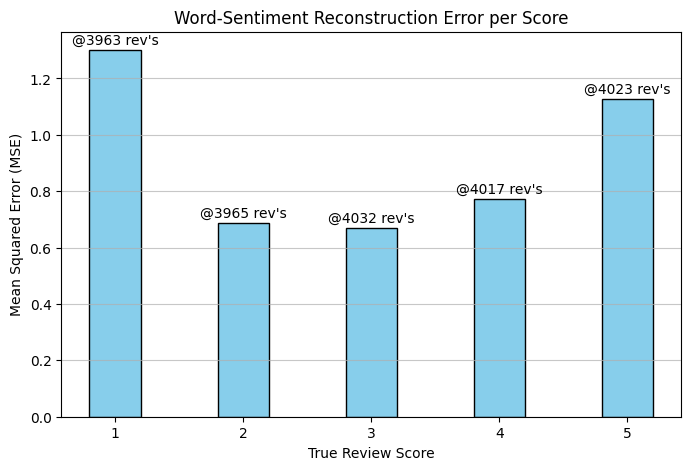

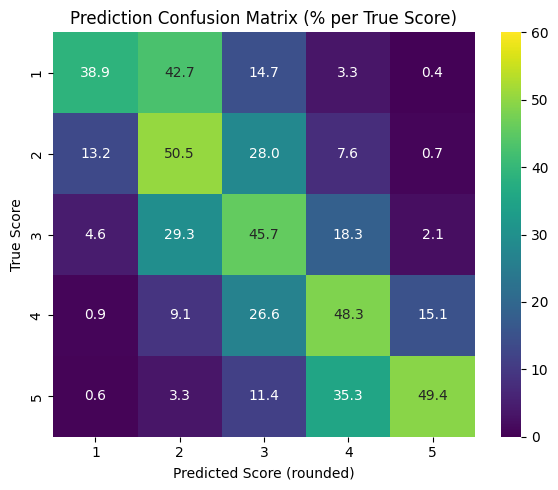

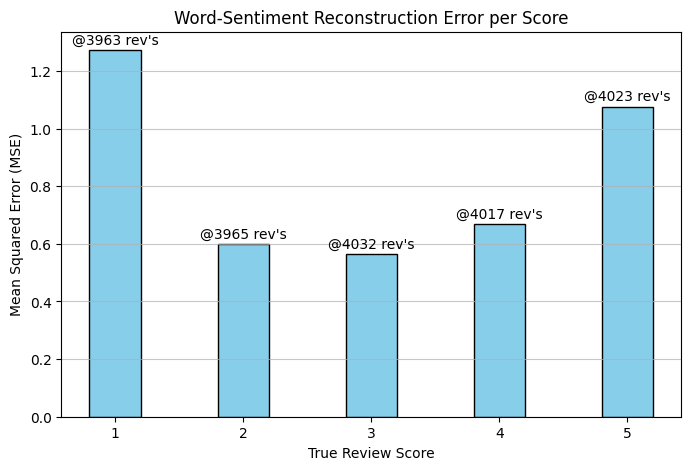

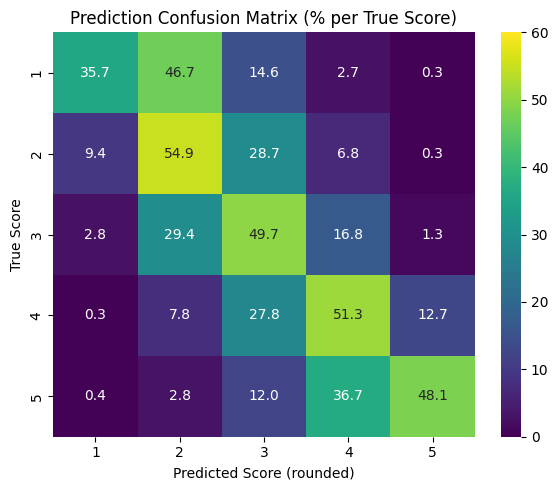

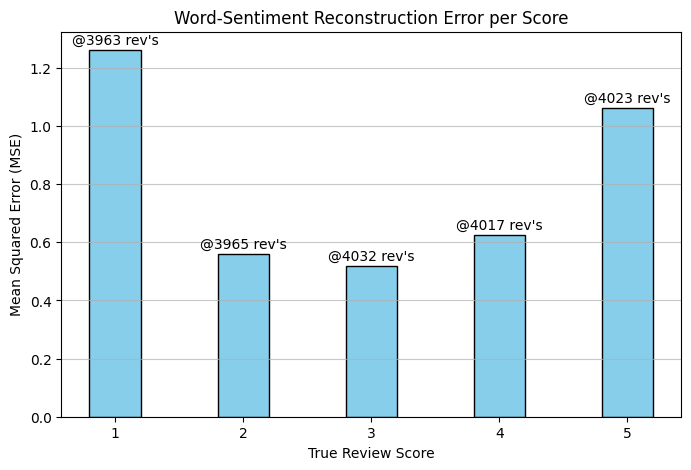

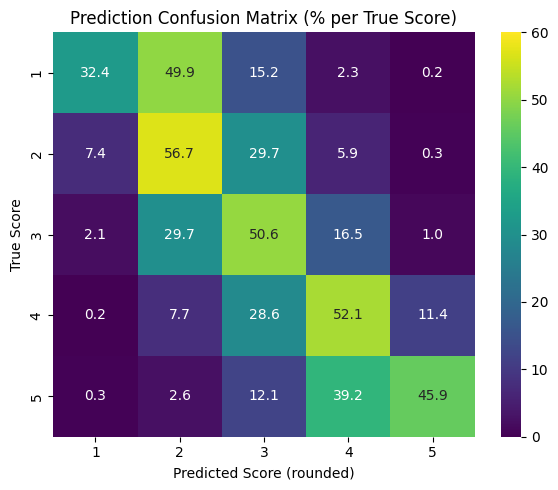

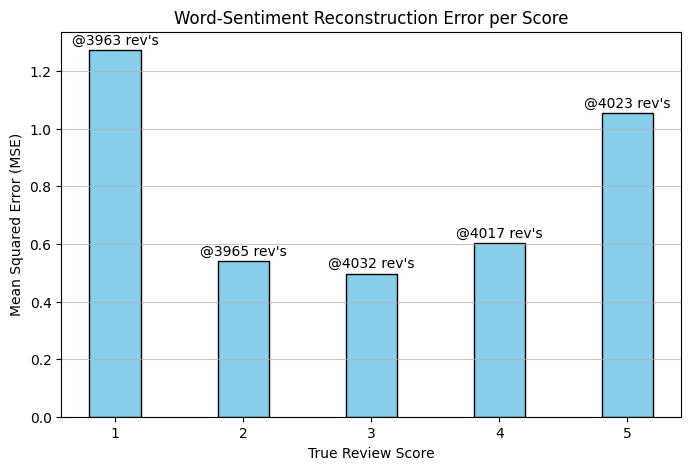

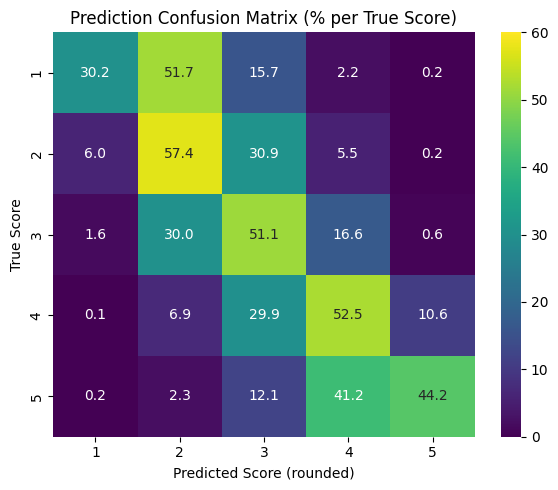

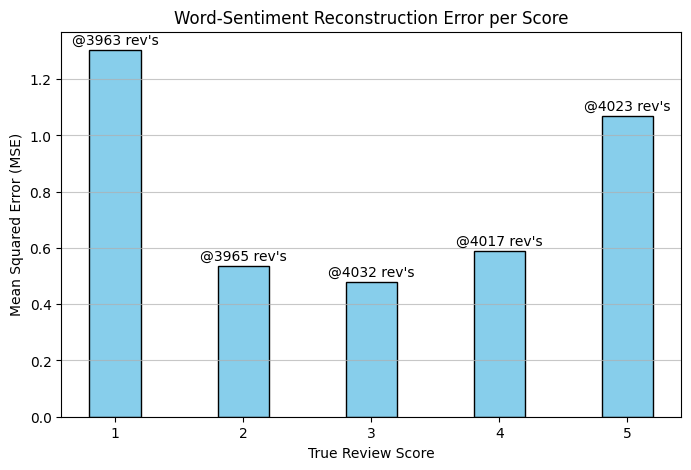

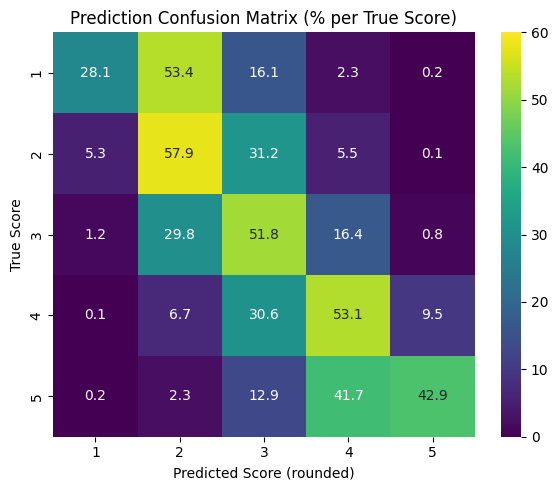

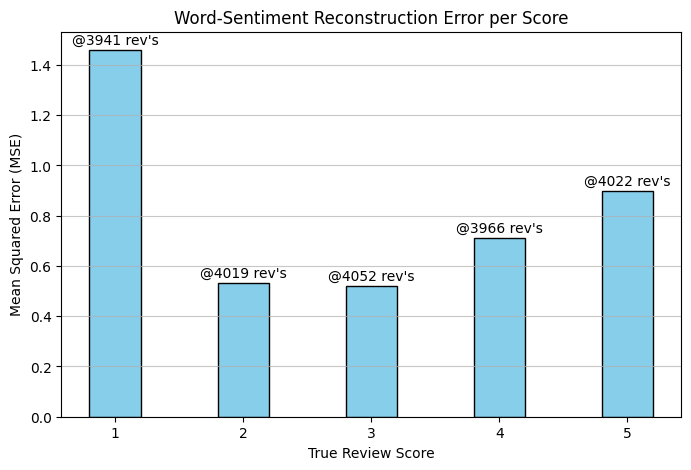

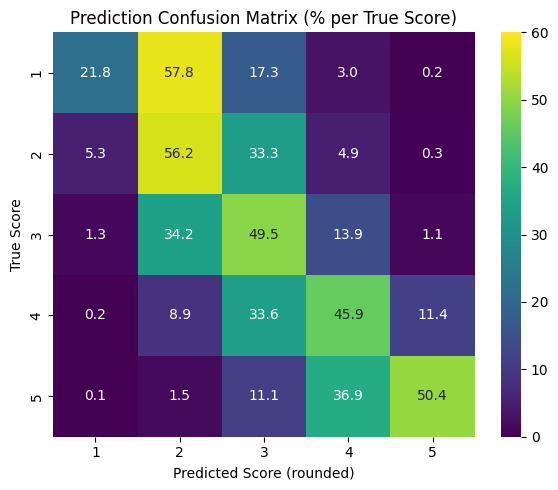

In [30]:
cache_dir = os.path.join(PROJECT_ROOT, "cache")
index = build_embedding_index(train_ds, model, tokenizer, cache_dir)

k_values = [5, 10, 20, 40, 80]
best_mse = np.inf
best_k = 0
for k in k_values:
    mse = estimate_ratings_with_embeddings(val_ds, index, model, tokenizer, top_k=k)
    if mse < best_mse:
        print(f"      > New Best! k={k} - MSE: {mse:.4f}")
        best_mse = mse
        best_k = k
    else:
        print(f"                  k={k} - MSE: {mse:.4f}")

unknown = estimate_ratings_with_embeddings(
    test_ds, index, model, tokenizer, prefix="Test_", top_k=best_k
)

## Sarcasm Test

In [33]:

def process_sarcasm_folder(input_folder, output_file):
    """
    Reads all .txt files in the specified folder, extracts fields using regex,
    and saves them to a JSONL file.
    """
    
    # 1. Validation
    if not os.path.exists(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist.")
        return

    txt_files = glob.glob(os.path.join(input_folder, "*.txt"))
    if not txt_files:
        print(f"No .txt files found in '{input_folder}'.")
        return

    print(f"Found {len(txt_files)} files in '{input_folder}'. Processing...")

    processed_count = 0
    errors = 0

    # 2. Open Output File
    with open(output_file, 'w', encoding='utf-8') as outfile:
        
        # 3. Iterate through files
        for file_path in tqdm(txt_files, desc="Converting"):
            try:
                # Use errors='ignore' or 'replace' to handle non-utf-8 characters often found in older datasets
                with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
                    content = f.read()

                # 4. Extract Data using Regex
                # re.DOTALL is crucial for <REVIEW> to capture newlines inside the tag
                stars_match = re.search(r'<STARS>(.*?)</STARS>', content)
                title_match = re.search(r'<TITLE>(.*?)</TITLE>', content)
                review_match = re.search(r'<REVIEW>(.*?)</REVIEW>', content, re.DOTALL)

                if stars_match and title_match and review_match:
                    try:
                        # Convert stars to float (e.g., "5.0" -> 5.0)
                        rating = float(stars_match.group(1).strip())
                    except ValueError:
                        rating = None # Keep as None or skip if strict

                    title = title_match.group(1).strip()
                    review_text = review_match.group(1).strip()

                    # 5. Construct JSON Object
                    entry = {
                        "rating": rating,
                        "title": title,
                        "text": review_text
                    }

                    # 6. Write to JSONL (one JSON object per line)
                    outfile.write(json.dumps(entry) + '\n')
                    processed_count += 1
                else:
                    # Log files that don't match the format
                    # print(f"Skipping {os.path.basename(file_path)}: Missing tags.")
                    errors += 1

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                errors += 1

    print("\nProcessing Complete.")
    print(f"Successfully processed: {processed_count}")
    print(f"Skipped/Errors: {errors}")
    print(f"Output saved to: {output_file}")

input_folder = "Ironic" 
output_path = os.path.join(PROJECT_ROOT, "datasets", "sarcastic_reviews_new.jsonl")

if not os.path.exists(os.path.dirname(output_path)):
    if not os.path.exists(input_folder):
        print(f"Note: '{input_folder}' not found. Please set INPUT_FOLDER to your data path.")
    else:
        process_sarcasm_folder(input_folder, output_path)

In [34]:
index_list = list(range(0, 437))
test_ds_sarcasm = ReviewDataset(os.path.join(PROJECT_ROOT, "datasets", "sarcastic_reviews_new.jsonl"), index_list)


print(index_list)
print("Test size:", len(test_ds_sarcasm))
print("First training sample:", test_ds_sarcasm[0])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

Wordcloud - Sarcasm

Grouping reviews by rating...


Processing reviews: 100%|██████████| 437/437 [00:00<00:00, 8071.23it/s]


Generating word clouds for each rating...


  Rating 1: 8555 unique words, saved to Wordcloud_Rating1_tfidf.png
  Rating 2: 1621 unique words, saved to Wordcloud_Rating2_tfidf.png
  Rating 3: 1343 unique words, saved to Wordcloud_Rating3_tfidf.png
  Rating 4: 1004 unique words, saved to Wordcloud_Rating4_tfidf.png
  Rating 5: 4523 unique words, saved to Wordcloud_Rating5_tfidf.png

Generating comparison plot...
  Comparison plot saved to Wordcloud_Comparison_tfidf.png


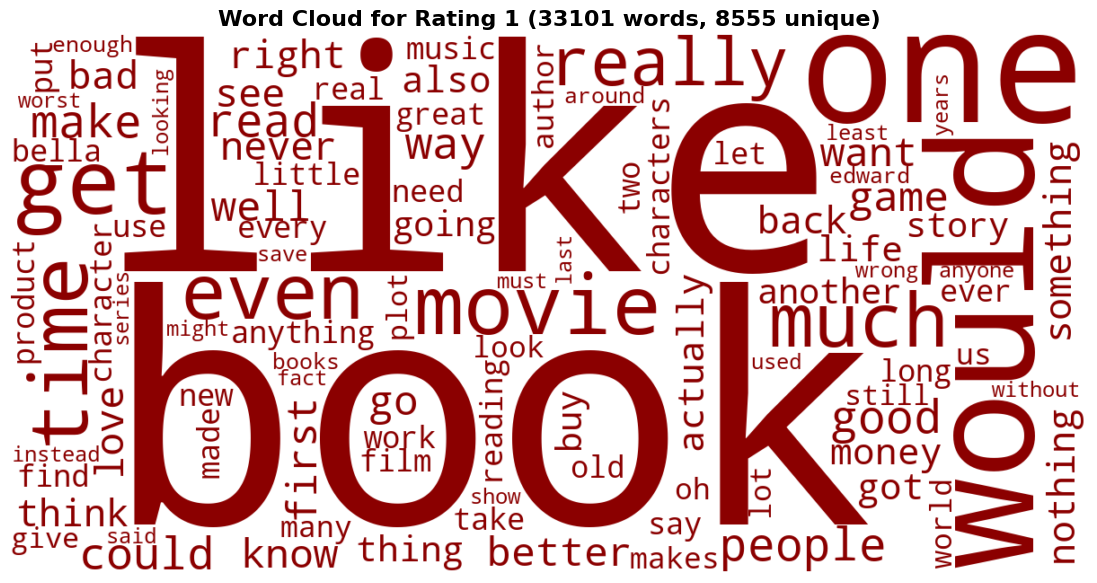

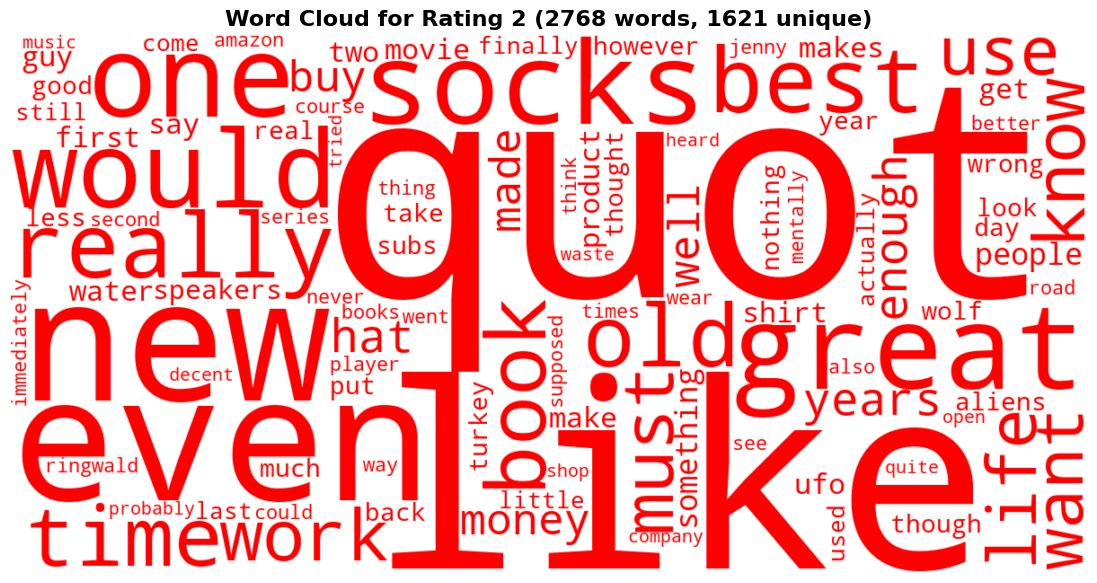

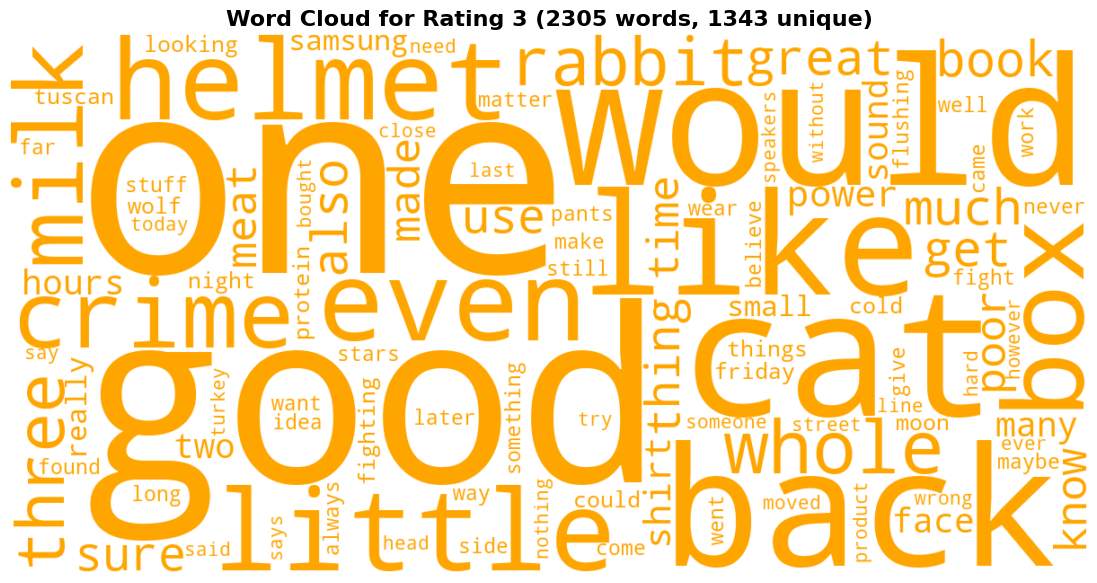

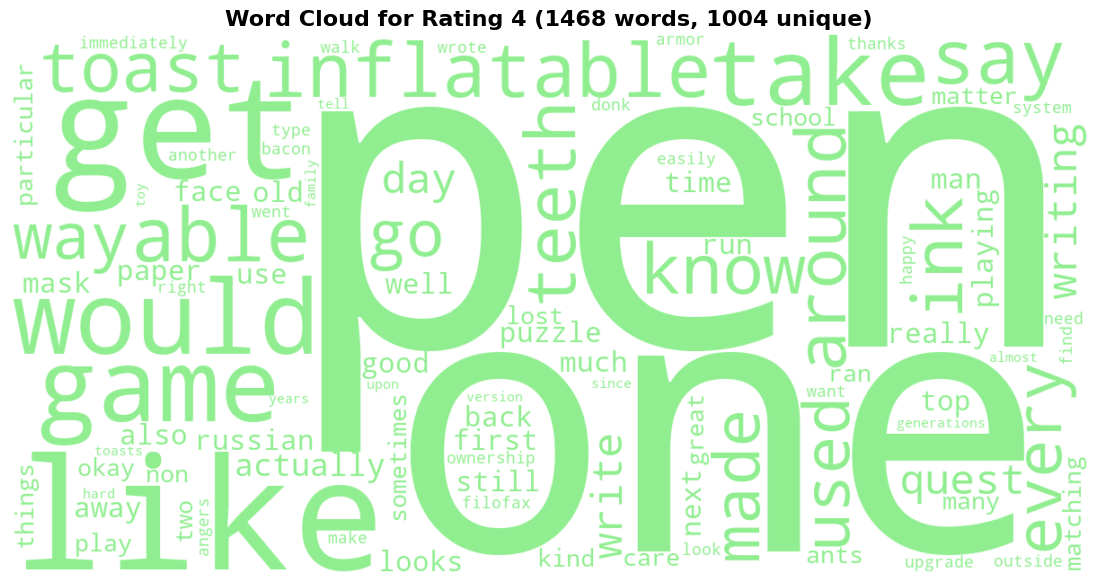

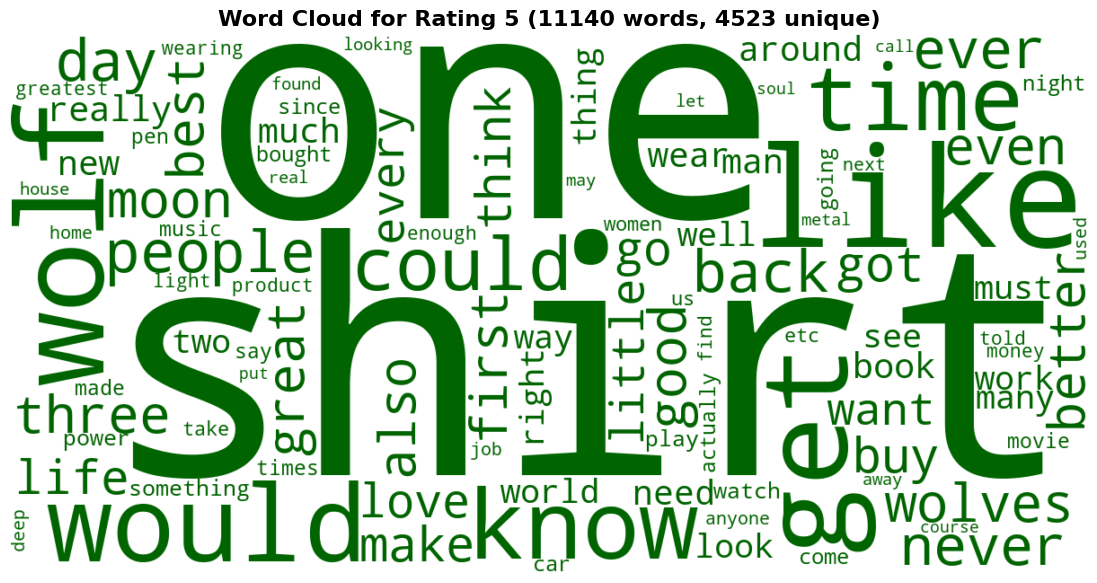

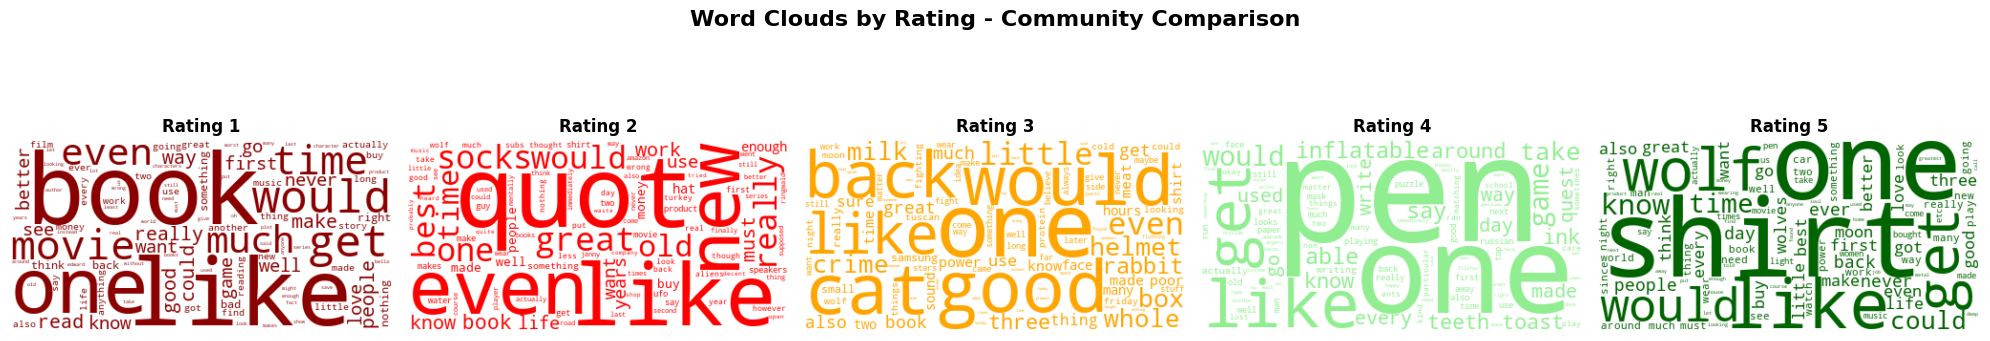

In [35]:
generate_rating_wordclouds(test_ds_sarcasm, prefix="", top_words=100)

Word Sentiment - Sarcasm

Running test: 100%|██████████| 437/437 [00:00<00:00, 6071.13it/s]


Overall MSE: 3.6286
Number of unknown words: 0


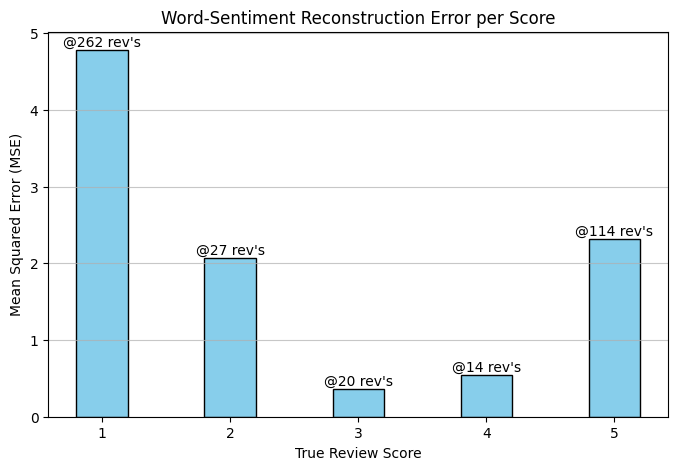

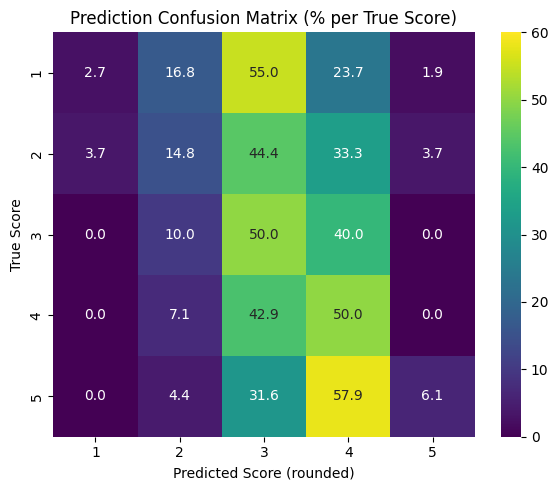

In [36]:
unknown_sarcasm = evaluate_word_sentiment_reconstruction(
    test_ds_sarcasm, word_stats, global_mean, global_std, prefix="Test_Sarcasm"
)
print("Number of unknown words:", unknown_sarcasm)

Preprocessing Test_sarcasm_ data...


Processing reviews: 100%|██████████| 437/437 [00:00<00:00, 7686.61it/s]

Vectorizing texts...
Making predictions...
Overall MSE: 3.1964


array([3.41432806, 2.98256433, 3.30598284, 3.05306114, 3.23641086,
       3.42139951, 3.24620147, 2.33980627, 3.27164614, 2.22871017,
       2.58669082, 2.48567875, 3.77875451, 2.99723123, 2.82958896,
       2.61293082, 3.47076048, 3.03345767, 2.97858167, 3.01516868,
       3.38818324, 2.86586953, 3.12169774, 3.00315799, 2.45082293,
       2.93475868, 3.28287635, 2.97613302, 3.23371088, 3.57669171,
       3.02968474, 2.40084828, 2.91272788, 3.19591059, 3.23614798,
       2.77604822, 3.16087544, 3.25652971, 2.85729823, 2.76084228,
       3.16446012, 2.81391937, 3.03405354, 3.01493037, 3.07698684,
       2.99474989, 3.13860473, 3.34537501, 3.33201924, 2.57574575,
       2.91443278, 2.66816178, 2.92543305, 2.89723367, 2.84809737,
       2.89684832, 3.07462621, 2.80695114, 3.26528152, 3.47378625,
       3.05419007, 2.97320988, 3.07591937, 2.65984074, 2.40353478,
       2.82596194, 3.01068399, 3.16112326, 2.63221595, 3.26794145,
       1.93098075, 3.14338311, 3.42992934, 3.25628343, 3.15120

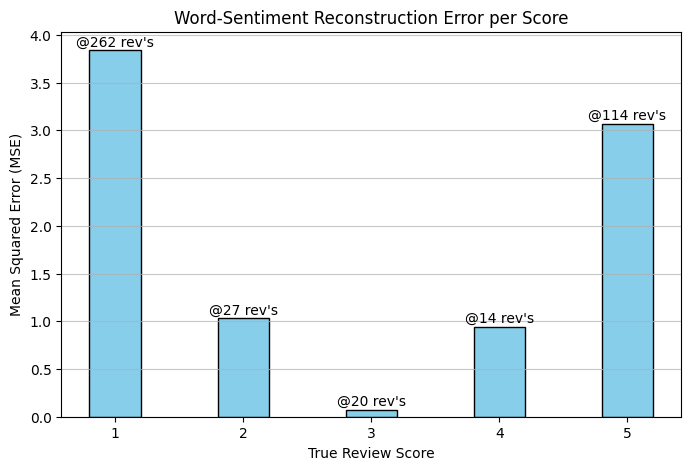

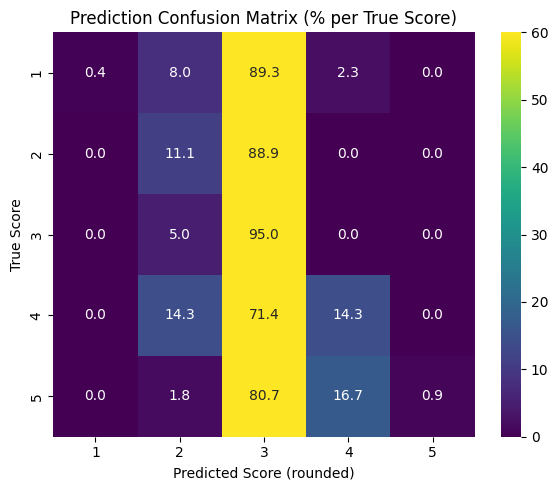

In [37]:
predict_tfidf(test_ds_sarcasm, vectorizer_ridge, model_ridge, "ridge", prefix="Test_sarcasm_")

Preprocessing Test_Sarcasm_ data...


Processing reviews: 100%|██████████| 437/437 [00:00<00:00, 8006.01it/s]

Vectorizing texts...
Making predictions...
Overall MSE: 3.6064


array([5., 3., 1., 5., 3., 4., 1., 1., 5., 1., 2., 1., 4., 1., 2., 1., 4.,
       1., 4., 3., 5., 1., 5., 1., 1., 1., 5., 1., 5., 5., 1., 1., 2., 3.,
       5., 1., 3., 1., 2., 2., 3., 3., 1., 2., 5., 1., 1., 5., 5., 1., 1.,
       1., 3., 1., 3., 2., 2., 1., 5., 3., 4., 5., 4., 1., 1., 3., 3., 1.,
       3., 4., 3., 1., 5., 4., 4., 5., 1., 5., 4., 4., 1., 2., 4., 5., 1.,
       1., 1., 1., 1., 5., 1., 1., 1., 1., 1., 1., 4., 1., 5., 4., 1., 1.,
       5., 1., 5., 1., 5., 1., 5., 3., 5., 5., 2., 4., 1., 1., 3., 1., 5.,
       1., 1., 4., 3., 1., 1., 3., 4., 4., 2., 1., 5., 5., 5., 1., 1., 4.,
       5., 1., 5., 5., 5., 1., 1., 1., 5., 1., 5., 5., 2., 4., 3., 5., 5.,
       5., 2., 3., 1., 1., 1., 3., 1., 5., 1., 1., 2., 4., 1., 1., 4., 1.,
       5., 1., 2., 1., 1., 5., 4., 4., 4., 5., 1., 5., 5., 4., 4., 2., 3.,
       5., 5., 1., 2., 4., 3., 2., 5., 1., 3., 3., 4., 5., 4., 3., 4., 2.,
       1., 1., 3., 5., 5., 4., 1., 5., 5., 5., 5., 4., 3., 1., 3., 1., 1.,
       1., 1., 1., 1., 1.

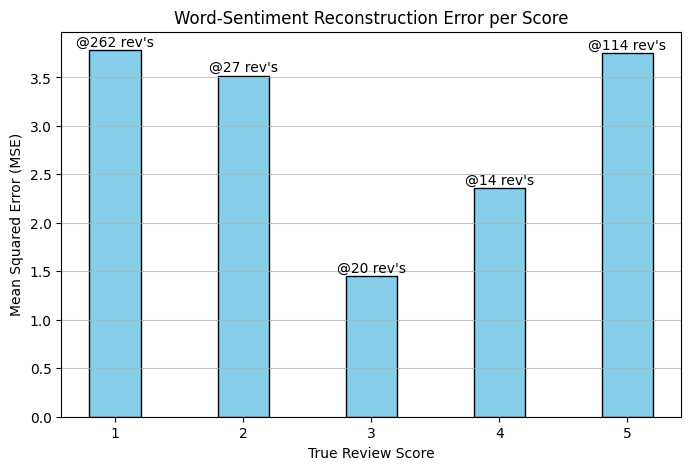

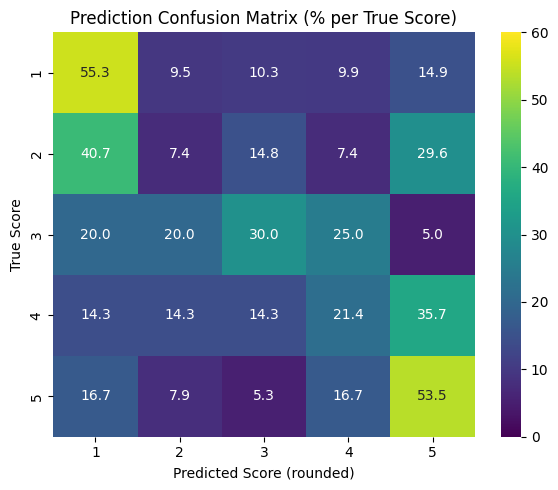

In [38]:
predict_tfidf(test_ds_sarcasm, vectorizer_log, model_log, "logistic", prefix="Test_Sarcasm_")

LSH - Sarcasm


Running LSH Prediction on Test_Sarcasm_ set (top_k=20)...


Predicting: 100%|██████████| 437/437 [00:19<00:00, 21.96it/s]


Overall MSE: 3.9119


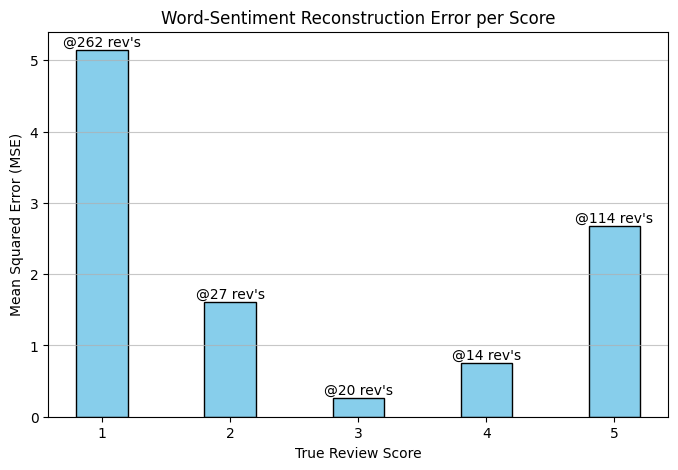

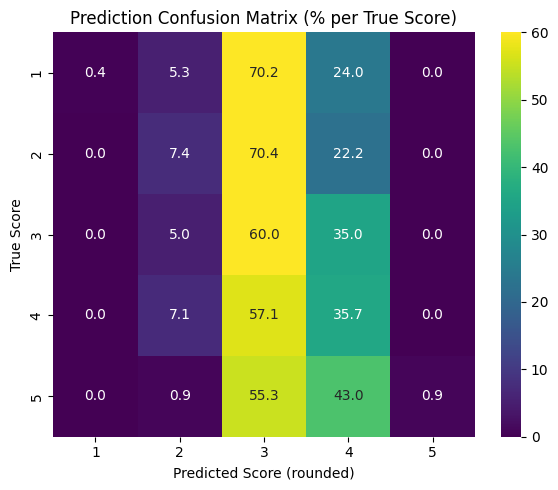

In [39]:
lsh_predict_test(test_ds_sarcasm, best_lsh, best_minhash, top_k=best_params[1], prefix="Test_Sarcasm_")

Clustering - Sarcasm


[Prediction] Starting prediction on Test_Sarcasm_ set (k=250, x=50)...
Overall MSE: 3.5491


0

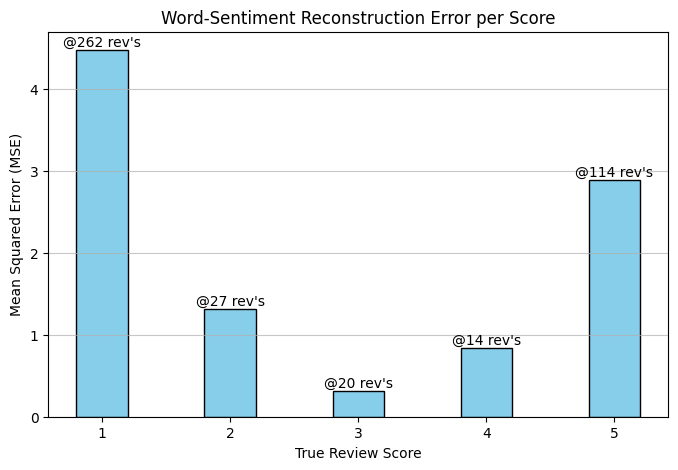

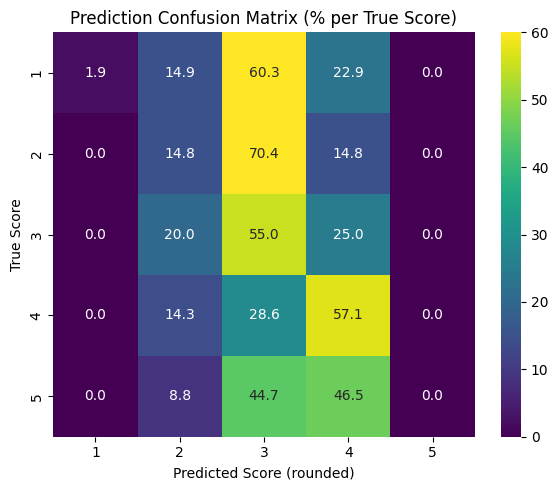

In [40]:
transformer_clustering_predict(
    test_ds_sarcasm, model, tokenizer, best_kmeans, best_ratings_map, prefix="Test_Sarcasm_", x=best_x
)

FAISS - Sarcasm

Running test: 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]


Overall MSE: 3.6032


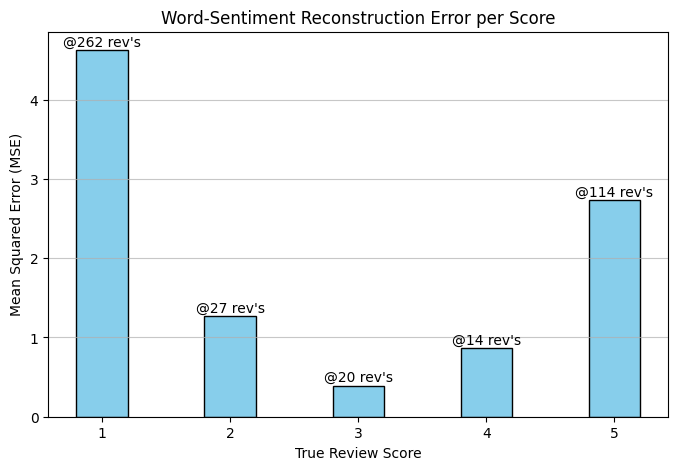

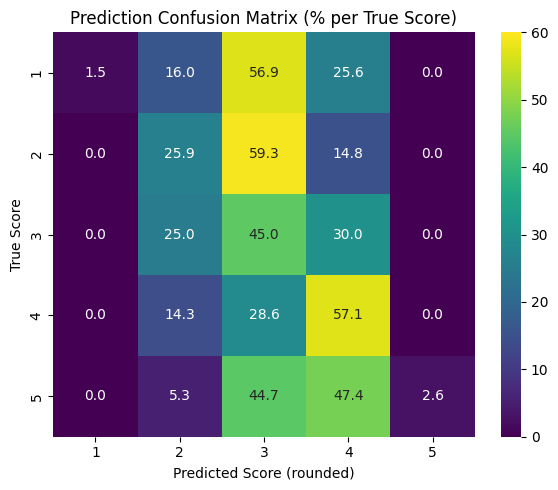

In [41]:
unknown_sarcasm_faiss = estimate_ratings_with_embeddings(
    test_ds_sarcasm, index, model, tokenizer, prefix="Test_Sarcasm", top_k=best_k
)